Visualization of G and D matrices for unimanual conditions

In [7]:
import os
import glob
import sys
sys.path.append('/Users/aghavamp/Desktop/Projects')
sys.path.append('/Users/aghavamp/Desktop/Projects/bimanual_wrist')
sys.path.append('/Users/aghavamp/Desktop/Projects/Functional_Fusion')
sys.path.append('/Users/aghavamp/Desktop/Projects/PcmPy')
import getpass
import importlib
from tqdm import tqdm
from pathlib import Path

from rsatoolbox.io import spm as spm_io
import surfAnalysisPy as surf
import SUITPy as suit
import nibabel as nb
import nitools as nt
import PcmPy as pcm
import Functional_Fusion.atlas_map as am
import Functional_Fusion.reliability as rel

import matplotlib.pyplot as plt
import matplotlib
from matplotlib.cm import ScalarMappable
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import matplotlib.patches as patches
import seaborn as sns

import scipy.io as sio
import numpy as np
import pandas as pd

import utils
importlib.reload(utils)

# SET PATHS:
baseDir = os.path.join('/Users', getpass.getuser(), 'Desktop', 'Projects', 'bimanual_wrist', 'data', 'fMRI')
bidsDir = 'BIDS'
anatomicalDir = 'anatomicals'
freesurferDir = 'surfaceFreesurfer'
surfacewbDir = 'surfaceWB' 
behavDir = 'behavioural'
regDir = 'ROI'
atlasDir = '/Volumes/diedrichsen_data$/data/Atlas_templates/fs_LR_32'
analysisDir = os.path.join(os.path.dirname(os.path.dirname(baseDir)), 'analysis')



# Unimanual 6by6

TypeError: 'Axes' object is not subscriptable

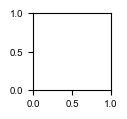

In [18]:
labels = ['flx', 'flxup', 'extup', 'ext', 'extdn', 'flxdn']
cmap = 'RdBu_r'
sn_bad = [102,103]
regions = ['M1','S1','PMd','PMv','SMA','SPLa','SPLp','V1']
conditions = ['lhand','rhand','lhand','rhand']

dataset_unimanual_within = {'region':[], 'hem': [], 'type': [], 'labels': [], 'Y': []}
RDMs_uni = {'region':[], 'labels': [], 'G': [], 'D': []}

for i_region, region in enumerate(regions):
    rois = [f'{region}_R', f'{region}_L', f'{region}_L', f'{region}_R']
    for roi, condition in zip(rois, conditions):
        data, cond_vec, part_vec = [], [], []
        file_path = os.path.join(analysisDir, f'pwbeta_{roi}.npz')
        d = np.load(file_path, allow_pickle=True)

        subject = d['subject']
        indices = [k for k, s in enumerate(subject) if s not in sn_bad]

        subject = d['subject'][indices]
        cond_name_tmp = d['cond_intrinsic_vec'][indices]
        cond_vec_tmp = d['cond_num_vec'][indices]
        data_tmp = d['beta_white'][indices]
        part_tmp = d['part_vec'][indices]

        for i_sub in range(len(subject)):
            if condition == 'lhand':
                if roi.endswith('_R'):
                    cond_type = 'contra'
                else:
                    cond_type = 'ipsi'
            if condition == 'rhand':
                if roi.endswith('_L'):
                    cond_type = 'contra'
                else:
                    cond_type = 'ipsi'
            
            # Filter for the current condition
            idx = [j for j, c in enumerate(cond_name_tmp[i_sub]) if condition in c]
            Y = data_tmp[i_sub][idx, :]
            subj_cond = cond_vec_tmp[i_sub][idx]
            subj_part = part_tmp[i_sub][idx]

            data.append(Y)
            cond_vec.append(np.array(subj_cond))
            part_vec.append(subj_part)

        Y = []
        # --- RDM Calculation ---
        for i_sub in range(len(data)):
            obs_des = {'cond_vec': cond_vec[i_sub], 'part_vec': part_vec[i_sub]}
            Y.append(pcm.dataset.Dataset(data[i_sub], obs_descriptors=obs_des))
        
        dataset_unimanual_within['region'].append(region)
        dataset_unimanual_within['hem'].append(roi[-1])
        dataset_unimanual_within['type'].append(cond_type)
        dataset_unimanual_within['labels'].append(labels)
        dataset_unimanual_within['Y'].append(Y)

dataset_unimanual_within = pd.DataFrame(dataset_unimanual_within)
dataset_unimanual_within.to_pickle(os.path.join(analysisDir, 'dataset_unimanual_within.pkl'))

# --- avg RDM --- 
plt.rcParams.update({'font.size': 7})
for i, region in enumerate(regions):
    fig, axes = plt.subplots(figsize=(1,1))
    subset = dataset_unimanual_within[(dataset_unimanual_within['region'] == f'{region}')]
    Y1 = subset['Y'].iloc[0]
    Y2 = subset['Y'].iloc[1]
    Y = Y1 + Y2  # concatenate the two lists of datasets
    labels = subset['labels'].iloc[0]
    N = len(Y)
    ncond = len(labels)
    G_hat = np.zeros((N, ncond, ncond))
    for i_sub in range(N):
        G_hat[i_sub, :, :], _ = pcm.est_G_crossval(Y[i_sub].measurements,
                                                    Y[i_sub].obs_descriptors['cond_vec'],
                                                    Y[i_sub].obs_descriptors['part_vec'],
                                                    X=pcm.matrix.indicator(Y[i_sub].obs_descriptors['part_vec']))
    
    G_hat_avg = np.mean(G_hat, axis=0)
    D_avg = pcm.G_to_dist(G_hat_avg)
    D_avg = np.sign(D_avg) * np.sqrt(np.abs(D_avg))
    vmin = -np.max(np.abs(D_avg))
    vmax = np.max(np.abs(D_avg))
    axes[0, i].imshow(D_avg,vmin=vmin,vmax=vmax,cmap=cmap)
    # color bar:
    sm = ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=-vmax, vmax=vmax))
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=axes[0, i], fraction=0.046, pad=0.04)
    cbar.ax.tick_params(labelsize=8)
    axes[0, i].set_title(f'{region} contra')
    axes[0, i].set_xticks(np.arange(len(labels)))
    axes[0,i].set_xticklabels(labels, rotation=30, ha='right')
    axes[0, i].set_yticks(np.arange(len(labels)))
    axes[0,i].set_yticklabels(labels, ha='right')

    vmin = -np.max(np.abs(G_hat_avg))
    vmax = np.max(np.abs(G_hat_avg))
    axes2[0, i].imshow(G_hat_avg,vmin=vmin,vmax=vmax,cmap=cmap)
    # color bar:
    sm = ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=-vmax, vmax=vmax))
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=axes2[0, i], fraction=0.046, pad=0.04)
    cbar.ax.tick_params(labelsize=8)
    axes2[0, i].set_title(f'{region} contra G')
    axes2[0, i].set_xticks(np.arange(len(labels)))
    axes2[0,i].set_xticklabels(labels, rotation=30, ha='right')
    axes2[0, i].set_yticks(np.arange(len(labels)))
    axes2[0,i].set_yticklabels(labels, ha='right')

# --- RDM Calculation ---
plt.rcParams.update({'font.size': 8})
fig, axes = plt.subplots(2, len(regions), figsize=(17,4), sharey=True)
fig2, axes2 = plt.subplots(2, len(regions), figsize=(17,4), sharey=True)
for i, region in enumerate(regions):
    subset = dataset_unimanual_within[(dataset_unimanual_within['region'] == f'{region}') & 
                                        (dataset_unimanual_within['type'] == 'contra')]
    Y1 = subset['Y'].iloc[0]
    Y2 = subset['Y'].iloc[1]
    Y = Y1 + Y2  # concatenate the two lists of datasets
    labels = subset['labels'].iloc[0]
    N = len(Y)
    ncond = len(labels)
    G_hat = np.zeros((N, ncond, ncond))
    for i_sub in range(N):
        G_hat[i_sub, :, :], _ = pcm.est_G_crossval(Y[i_sub].measurements,
                                                    Y[i_sub].obs_descriptors['cond_vec'],
                                                    Y[i_sub].obs_descriptors['part_vec'],
                                                    X=pcm.matrix.indicator(Y[i_sub].obs_descriptors['part_vec']))
    
    G_hat_avg = np.mean(G_hat, axis=0)
    D_avg = pcm.G_to_dist(G_hat_avg)
    D_avg = np.sign(D_avg) * np.sqrt(np.abs(D_avg))
    vmin = -np.max(np.abs(D_avg))
    vmax = np.max(np.abs(D_avg))
    axes[0, i].imshow(D_avg,vmin=vmin,vmax=vmax,cmap=cmap)
    # color bar:
    sm = ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=-vmax, vmax=vmax))
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=axes[0, i], fraction=0.046, pad=0.04)
    cbar.ax.tick_params(labelsize=8)
    axes[0, i].set_title(f'{region} contra')
    axes[0, i].set_xticks(np.arange(len(labels)))
    axes[0,i].set_xticklabels(labels, rotation=30, ha='right')
    axes[0, i].set_yticks(np.arange(len(labels)))
    axes[0,i].set_yticklabels(labels, ha='right')

    vmin = -np.max(np.abs(G_hat_avg))
    vmax = np.max(np.abs(G_hat_avg))
    axes2[0, i].imshow(G_hat_avg,vmin=vmin,vmax=vmax,cmap=cmap)
    # color bar:
    sm = ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=-vmax, vmax=vmax))
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=axes2[0, i], fraction=0.046, pad=0.04)
    cbar.ax.tick_params(labelsize=8)
    axes2[0, i].set_title(f'{region} contra G')
    axes2[0, i].set_xticks(np.arange(len(labels)))
    axes2[0,i].set_xticklabels(labels, rotation=30, ha='right')
    axes2[0, i].set_yticks(np.arange(len(labels)))
    axes2[0,i].set_yticklabels(labels, ha='right')
    
    subset = dataset_unimanual_within[(dataset_unimanual_within['region'] == f'{region}') & 
                                        (dataset_unimanual_within['type'] == 'ipsi')]
    Y1 = subset['Y'].iloc[0]
    Y2 = subset['Y'].iloc[1]
    Y = Y1 + Y2  # concatenate the two lists of datasets
    labels = subset['labels'].iloc[0]
    N = len(Y)
    ncond = len(labels)
    G_hat = np.zeros((N, ncond, ncond))
    for i_sub in range(N):
        G_hat[i_sub, :, :], _ = pcm.est_G_crossval(Y[i_sub].measurements,
                                                    Y[i_sub].obs_descriptors['cond_vec'],
                                                    Y[i_sub].obs_descriptors['part_vec'],
                                                    X=pcm.matrix.indicator(Y[i_sub].obs_descriptors['part_vec']))
    G_hat_avg = np.mean(G_hat, axis=0)
    D_avg = pcm.G_to_dist(G_hat_avg)
    D_avg = np.sign(D_avg) * np.sqrt(np.abs(D_avg))
    vmin = -np.max(np.abs(D_avg))
    vmax = np.max(np.abs(D_avg))
    axes[1, i].imshow(D_avg,vmin=vmin,vmax=vmax,cmap=cmap)
    # color bar:
    sm = ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=-vmax, vmax=vmax))
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=axes[1, i], fraction=0.046, pad=0.04)
    cbar.ax.tick_params(labelsize=8)
    axes[1, i].set_title(f'{region} ipsi')
    axes[1, i].set_xticks(np.arange(len(labels)))
    axes[1,i].set_xticklabels(labels, rotation=30, ha='right')
    axes[1, i].set_yticks(np.arange(len(labels)))
    axes[1,i].set_yticklabels(labels, ha='right')

    vmin = -np.max(np.abs(G_hat_avg))
    vmax = np.max(np.abs(G_hat_avg))
    axes2[1, i].imshow(G_hat_avg,vmin=vmin,vmax=vmax,cmap=cmap)
    # color bar:
    sm = ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=-vmax, vmax=vmax))
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=axes2[1, i], fraction=0.046, pad=0.04)
    cbar.ax.tick_params(labelsize=8)
    axes2[1, i].set_title(f'{region} ipsi G')
    axes2[1, i].set_xticks(np.arange(len(labels)))
    axes2[1,i].set_xticklabels(labels, rotation=30, ha='right')
    axes2[1, i].set_yticks(np.arange(len(labels)))
    axes2[1,i].set_yticklabels(labels, ha='right')

fig.tight_layout()
fig.show()
fig2.tight_layout()
fig2.show()

# single subject Distances:
# region = 'M1'
# subset = dataset_unimanual_within[(dataset_unimanual_within['region'] == f'{region}') & 
#                                     (dataset_unimanual_within['type'] == 'contra')]
# Y1 = subset['Y'].iloc[0]
# Y2 = subset['Y'].iloc[1]
# Y = Y1 + Y2  # concatenate the two lists of datasets
# labels = subset['labels'].iloc[0]
# N = len(Y)//2
# ncond = len(labels)
# G_hat = np.zeros((N, ncond, ncond))
# fig, axes = plt.subplots(1, N, figsize=(15,4), sharey=True)
# for i_sub in range(N):
#         G_hat[i_sub, :, :], _ = pcm.est_G_crossval(Y[i_sub].measurements,
#                                                     Y[i_sub].obs_descriptors['cond_vec'],
#                                                     Y[i_sub].obs_descriptors['part_vec'],
#                                                     X=pcm.matrix.indicator(Y[i_sub].obs_descriptors['part_vec']))
#         D_hat = pcm.G_to_dist(G_hat[i_sub, :, :])
#         D_hat = np.sign(D_hat) * np.sqrt(np.abs(D_hat))
#         vmin = -np.max(np.abs(D_hat))
#         vmax = np.max(np.abs(D_hat))
#         axes[i_sub].imshow(D_hat,vmin=vmin,vmax=vmax,cmap=cmap)
#         axes[i_sub].set_title(f'sub{i_sub+1}, {region} contra')
#         # plt.colorbar(axes[i_sub].images[0], ax=axes[i_sub])
#         axes[i_sub].set_xticks(np.arange(len(labels)))
#         axes[i_sub].set_xticklabels(labels, rotation=30, ha='right')
#         axes[i_sub].set_yticks(np.arange(len(labels)))
#         axes[i_sub].set_yticklabels(labels, ha='right')
# plt.tight_layout()
# plt.show()


# region = 'M1'
# subset = dataset_unimanual_within[(dataset_unimanual_within['region'] == f'{region}') & 
#                                     (dataset_unimanual_within['type'] == 'ipsi')]
# Y1 = subset['Y'].iloc[0]
# Y2 = subset['Y'].iloc[1]
# Y = Y1 + Y2  # concatenate the two lists of datasets
# labels = subset['labels'].iloc[0]
# N = len(Y)//2
# ncond = len(labels)
# G_hat = np.zeros((N, ncond, ncond))
# fig, axes = plt.subplots(1, N, figsize=(15,4), sharey=True)
# for i_sub in range(N):
#         G_hat[i_sub, :, :], _ = pcm.est_G_crossval(Y[i_sub].measurements,
#                                                     Y[i_sub].obs_descriptors['cond_vec'],
#                                                     Y[i_sub].obs_descriptors['part_vec'],
#                                                     X=pcm.matrix.indicator(Y[i_sub].obs_descriptors['part_vec']))
#         D_hat = pcm.G_to_dist(G_hat[i_sub, :, :])
#         D_hat = np.sign(D_hat) * np.sqrt(np.abs(D_hat))
#         vmin = -np.max(np.abs(D_hat))
#         vmax = np.max(np.abs(D_hat))
#         axes[i_sub].imshow(D_hat,vmin=vmin,vmax=vmax,cmap=cmap)
#         axes[i_sub].set_title(f'sub{i_sub+1}, {region} ipsi')
#         # plt.colorbar(axes[i_sub].images[0], ax=axes[i_sub])
#         axes[i_sub].set_xticks(np.arange(len(labels)))
#         axes[i_sub].set_xticklabels(labels, rotation=30, ha='right')
#         axes[i_sub].set_yticks(np.arange(len(labels)))
#         axes[i_sub].set_yticklabels(labels, ha='right')
# plt.tight_layout()
# plt.show()




# Unimanual contra

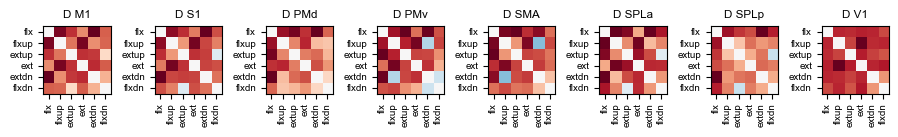

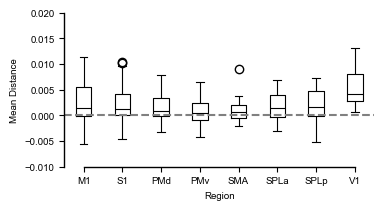

Region: M1, t(23): 3.0122811299816683, p-value: 0.0031043054990988472
Region: S1, t(23): 3.18743499600667, p-value: 0.002049937082282035
Region: PMd, t(23): 2.906753913750062, p-value: 0.003973003178127924
Region: PMv, t(23): 1.9104210652143274, p-value: 0.03431242507332709
Region: SMA, t(23): 2.438142176935439, p-value: 0.011450906561196548
Region: SPLa, t(23): 3.335232970747328, p-value: 0.00143768679265399
Region: SPLp, t(23): 3.3956489045866256, p-value: 0.001242289398091194
Region: V1, t(23): 7.448612198446589, p-value: 7.140277668573489e-08


In [21]:
labels = ['flx', 'flxup', 'extup', 'ext', 'extdn', 'flxdn']
cmap = 'RdBu_r'
sn_bad = [102,103]
regions = ['M1','S1','PMd','PMv','SMA','SPLa','SPLp','V1']
conditions = ['rhand', 'lhand']
df = {'sn':[], 'roi':[], 'hem':[], 'distances':[], 'mean_distance':[]}

RDMs_contra = {'region':[], 'labels': [], 'G': [], 'D': []}

plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 7
fig, axes = plt.subplots(1, len(regions), figsize=(9,3))
for i_region, region in enumerate(regions):
    rois = [f'{region}_L', f'{region}_R']
    data, cond_vec, part_vec = [], [], []
    for roi, condition in zip(rois, conditions):
        file_path = os.path.join(analysisDir, f'pwbeta_{roi}.npz')
        d = np.load(file_path, allow_pickle=True)
        
        subject = d['subject']
        indices = [k for k, s in enumerate(subject) if s not in sn_bad]

        subject = d['subject'][indices]
        cond_name_tmp = d['cond_intrinsic_vec'][indices]
        cond_vec_tmp = d['cond_num_vec'][indices]
        data_tmp = d['beta_white'][indices]
        part_tmp = d['part_vec'][indices]

        for i_sub in range(len(subject)):
            # Filter for the current condition
            if condition == 'lhand_marginal':
                Y = []
                subj_part = []
                subj_cond = []
                # loop on each direction
                for cond_num, direction in enumerate(labels):
                    # in each partition:
                    for k in range(1,11):
                        # bimanual trials that left hand goes in that direction:
                        tmp_name = f'bi:{direction}_'
                        idx1 = np.array([(tmp_name in tmp) for tmp in cond_name_tmp[i_sub]])
                        idx2 = np.array([(k == tmp) for tmp in part_tmp[i_sub]])
                        idx = idx1 & idx2
                        y_tmp = np.mean(data_tmp[i_sub][idx,:], axis=0)
                        Y = np.vstack((Y, y_tmp)) if len(Y) else y_tmp
                    subj_part = np.int64(np.concatenate((subj_part,np.arange(1,11))))
                    condition_name = f'lhand:{direction}'
                    # find the condition numbers corresponding to this condition:
                    idx = (cond_name_tmp[i_sub] == condition_name) & (part_tmp[i_sub] == 1)
                    subj_cond.extend([cond_vec_tmp[i_sub][idx][0]] * 10)

            if condition == 'rhand_marginal':
                Y = []
                subj_part = []
                subj_cond = []
                # loop on each direction
                for cond_num, direction in enumerate(labels):
                    # in each partition:
                    for k in range(1,11):
                        # bimanual trials that right hand goes in that direction:
                        tmp_name = f'_{direction}'
                        idx1 = np.array([(tmp_name in tmp) for tmp in cond_name_tmp[i_sub]])
                        idx2 = np.array([(k == tmp) for tmp in part_tmp[i_sub]])
                        idx = idx1 & idx2
                        y_tmp = np.mean(data_tmp[i_sub][idx,:], axis=0)
                        Y = np.vstack((Y, y_tmp)) if len(Y) else y_tmp
                    subj_part = np.int64(np.concatenate((subj_part,np.arange(1,11))))
                    condition_name = f'rhand:{direction}'
                    # find the condition numbers corresponding to this condition:
                    idx = (cond_name_tmp[i_sub] == condition_name) & (part_tmp[i_sub] == 1)
                    subj_cond.extend([cond_vec_tmp[i_sub][idx][0]] * 10)

            if condition == 'lhand' or condition == 'rhand':
                # Filter for the current condition
                idx = [j for j, c in enumerate(cond_name_tmp[i_sub]) if condition in c]
                Y = data_tmp[i_sub][idx, :]
                subj_cond = cond_vec_tmp[i_sub][idx]
                subj_part = part_tmp[i_sub][idx]

            data.append(Y)
            cond_vec.append(np.array(subj_cond))
            part_vec.append(subj_part)

    Y = []
    # --- RDM Calculation ---
    for i_sub in range(len(data)):
        obs_des = {'cond_vec': cond_vec[i_sub], 'part_vec': part_vec[i_sub]}
        Y.append(pcm.dataset.Dataset(data[i_sub], obs_descriptors=obs_des))
    
    N = len(Y)
    ncond = 6
    G_hat = np.zeros((N, ncond, ncond))
    for i_sub in range(N):
        G_hat[i_sub, :, :], _ = pcm.est_G_crossval(Y[i_sub].measurements,
                                                    Y[i_sub].obs_descriptors['cond_vec'],
                                                    Y[i_sub].obs_descriptors['part_vec'],
                                                    X=pcm.matrix.indicator(Y[i_sub].obs_descriptors['part_vec']))
        dist = pcm.G_to_dist(G_hat[i_sub, :, :])
        dist = np.sign(dist) * np.sqrt(np.abs(dist))
        # select the upper triangle of d excluding the diagonal
        triu_indices = np.triu_indices(ncond, k=1)
        d_upper = dist[triu_indices]
        # save in df:
        df['distances'].append(d_upper)
        df['mean_distance'].append(np.mean(d_upper))
        df['roi'].append(region)
        # if i_sub is bigger than len of subject:
        if i_sub > len(subject)-1:
            df['sn'].append(subject[i_sub - len(subject)])
            df['hem'].append('R')
        else:
            df['sn'].append(subject[i_sub])
            df['hem'].append('L')

    G_hat_avg = np.mean(G_hat, axis=0)
    D_avg = pcm.G_to_dist(G_hat_avg)
    D_avg = np.sign(D_avg) * np.sqrt(np.abs(D_avg))
    RDMs_contra['region'].append(region)
    RDMs_contra['G'].append(G_hat_avg)
    RDMs_contra['D'].append(D_avg)
    RDMs_contra['labels'].append(labels)

    vmin = -np.max(np.abs(D_avg))
    vmax = np.max(np.abs(D_avg))
    axes[i_region].imshow(D_avg, cmap='RdBu_r', vmin=vmin, vmax=vmax)
    # plt.colorbar(axes[i_region].imshow(G, cmap='RdBu_r', vmin=vmin, vmax=vmax), ax=axes[i_region])
    axes[i_region].set_title(f'D {region}')
    axes[i_region].set_xticks([0,1,2,3,4,5])
    axes[i_region].set_xticklabels(labels, rotation=90)
    axes[i_region].set_yticks([0,1,2,3,4,5])
    axes[i_region].set_yticklabels(labels)

plt.tight_layout()
plt.savefig('/Users/aghavamp/Desktop/Projects/bimanual_wrist/figures/RDMs/RDM_uni_contra.pdf', bbox_inches='tight')
plt.show()

df_contra = pd.DataFrame(df)

# Create a dot plot for the mean distances
fig, ax = plt.subplots(figsize=(4, 2))
sns.boxplot(data=df_contra, x='roi', y='mean_distance', ax=ax, fill=False, color='black', width=0.4, linewidth=0.8)
ax.axhline(0, color='grey', linestyle='--', linewidth=1.5)
ax.set_xlabel('Region')
ax.set_ylabel('Mean Distance')
plt.ylim(-0.01, 0.02)
# ax.set_yticks([-0.05, 0, 0.1, 0.2])
utils.please.make_it_pretty(ax)
plt.savefig('/Users/aghavamp/Desktop/Projects/bimanual_wrist/figures/RDMs/avgdist_uni_contra.pdf', bbox_inches='tight')
plt.show()

# ttest > 0:
from scipy.stats import ttest_1samp
ttest_results = []
for i_region, region in enumerate(regions):
    # Get the distances for this region
    dists = df_contra['mean_distance'][df_contra['roi'] == region].values
    # Perform a one-sample t-test against the null hypothesis (mean = 0)
    t_stat, p_val = ttest_1samp(dists, 0, alternative='greater')
    print(f'Region: {region}, t({len(dists)-1}): {t_stat}, p-value: {p_val}')

RDMs_contra = pd.DataFrame(RDMs_contra)
RDMs_contra.to_pickle(os.path.join(analysisDir, 'RDMs_uni_contra.pkl'))



# Unimanual Ipsi

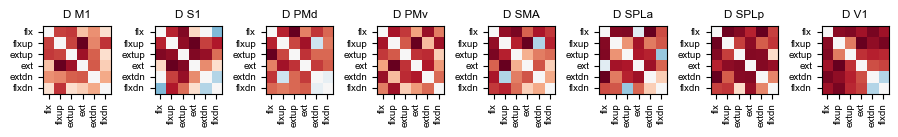

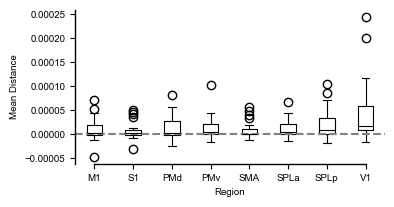

Region: M1, t(23): 2.030555398183992, p-value: 0.027008853699012167
Region: S1, t(23): 2.100953981537772, p-value: 0.023402923352513712
Region: PMd, t(23): 2.9643411791246237, p-value: 0.0034736494472036358
Region: PMv, t(23): 2.657765844987171, p-value: 0.007030260848010618
Region: SMA, t(23): 2.6158467822856832, p-value: 0.007725645075990284
Region: SPLa, t(23): 3.1308568265934635, p-value: 0.0023456181042419075
Region: SPLp, t(23): 3.4783836666226313, p-value: 0.0010161526219134604
Region: V1, t(23): 3.5044459131244636, p-value: 0.0009536387898725732


In [ ]:
labels = ['flx', 'flxup', 'extup', 'ext', 'extdn', 'flxdn']
cmap = 'RdBu_r'
sn_bad = [102,103]
regions = ['M1','S1','PMd','PMv','SMA','SPLa','SPLp','V1']
conditions = ['lhand','rhand']
df = {'sn':[], 'roi':[], 'hem':[], 'distances':[], 'mean_distance':[]}
RDMs_ipsi = {'region':[], 'labels': [], 'G': [], 'D': []}

plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 7
fig, axes = plt.subplots(1, len(regions), figsize=(9,3))
for i_region, region in enumerate(regions):
    rois = [f'{region}_L', f'{region}_R']
    data, cond_vec, part_vec = [], [], []
    for roi, condition in zip(rois, conditions):
        file_path = os.path.join(analysisDir, f'pwbeta_{roi}.npz')
        d = np.load(file_path, allow_pickle=True)

        subject = d['subject']
        indices = [k for k, s in enumerate(subject) if s not in sn_bad]

        subject = d['subject'][indices]
        cond_name_tmp = d['cond_intrinsic_vec'][indices]
        cond_vec_tmp = d['cond_num_vec'][indices]
        data_tmp = d['beta_white'][indices]
        part_tmp = d['part_vec'][indices]

        for i_sub in range(len(subject)):
            if condition == 'lhand' or condition == 'rhand':
                # Filter for the current condition
                idx = [j for j, c in enumerate(cond_name_tmp[i_sub]) if condition in c]
                Y = data_tmp[i_sub][idx, :]
                subj_cond = cond_vec_tmp[i_sub][idx]
                subj_part = part_tmp[i_sub][idx]

            data.append(Y)
            cond_vec.append(np.array(subj_cond))
            part_vec.append(subj_part)

    Y = []
    # --- RDM Calculation ---
    for i_sub in range(len(data)):
        obs_des = {'cond_vec': cond_vec[i_sub], 'part_vec': part_vec[i_sub]}
        Y.append(pcm.dataset.Dataset(data[i_sub], obs_descriptors=obs_des))
    
    N = len(Y)
    ncond = 6
    G_hat = np.zeros((N, ncond, ncond))
    for i_sub in range(N):
        G_hat[i_sub, :, :], _ = pcm.est_G_crossval(Y[i_sub].measurements,
                                                    Y[i_sub].obs_descriptors['cond_vec'],
                                                    Y[i_sub].obs_descriptors['part_vec'],
                                                    X=pcm.matrix.indicator(Y[i_sub].obs_descriptors['part_vec']))
        dist = pcm.G_to_dist(G_hat[i_sub, :, :])
        # dist = np.sign(dist) * np.sqrt(np.abs(dist))
        # select the upper triangle of d excluding the diagonal
        triu_indices = np.triu_indices(ncond, k=1)
        d_upper = dist[triu_indices]
        # save in df:
        df['distances'].append(d_upper)
        
        # gtmp = G_hat[i_sub, :, :]
        # distance_tmp = (gtmp.shape[0]-1)*np.trace(gtmp) - 2*np.sum(np.triu(gtmp, k=1))
        # distance_tmp = np.sum(np.triu(dist,k=1))
        # bs_sum = np.mean(d_upper)
        df['mean_distance'].append(np.mean(d_upper))
        df['roi'].append(region)
        # if i_sub is bigger than len of subject:
        if i_sub > len(subject)-1:
            df['sn'].append(subject[i_sub - len(subject)])
            df['hem'].append('R')
        else:
            df['sn'].append(subject[i_sub])
            df['hem'].append('L')

    G_hat_avg = np.mean(G_hat, axis=0)
    D_avg = pcm.G_to_dist(G_hat_avg)
    D_avg = np.sign(D_avg) * np.sqrt(np.abs(D_avg))
    RDMs_ipsi['region'].append(region)
    RDMs_ipsi['G'].append(G_hat_avg)
    RDMs_ipsi['D'].append(D_avg)
    RDMs_ipsi['labels'].append(labels)

    vmin = -np.max(np.abs(D_avg))
    vmax = np.max(np.abs(D_avg))
    axes[i_region].imshow(D_avg, cmap='RdBu_r', vmin=vmin, vmax=vmax)
    # plt.colorbar(axes[i_region].imshow(G, cmap='RdBu_r', vmin=vmin, vmax=vmax), ax=axes[i_region])
    axes[i_region].set_title(f'D {region}')
    axes[i_region].set_xticks([0,1,2,3,4,5])
    axes[i_region].set_xticklabels(labels, rotation=90)
    axes[i_region].set_yticks([0,1,2,3,4,5])
    axes[i_region].set_yticklabels(labels)

plt.tight_layout()
plt.savefig('/Users/aghavamp/Desktop/Projects/bimanual_wrist/figures/RDMs/RDM_uni_ipsi.pdf', bbox_inches='tight')
plt.show()

df_ipsi = pd.DataFrame(df)
# Create a dot plot for the mean distances
fig, ax = plt.subplots(figsize=(4, 2))
sns.boxplot(data=df_ipsi, x='roi', y='mean_distance', ax=ax, fill=False, color='black', width=0.4, linewidth=0.8)
ax.axhline(0, color='grey', linestyle='--', linewidth=1.5)
ax.set_xlabel('Region')
ax.set_ylabel('Mean Distance')
# plt.ylim(-0.01, 0.02)
# ax.set_yticks([-0.05, 0, 0.1, 0.2])
utils.please.make_it_pretty(ax)
plt.savefig('/Users/aghavamp/Desktop/Projects/bimanual_wrist/figures/RDMs/avgdist_uni_ipsi.pdf', bbox_inches='tight')
plt.show()

# ttest > 0:
from scipy.stats import ttest_1samp
ttest_results = []
for i_region, region in enumerate(regions):
    # Get the distances for this region
    dists = df_ipsi['mean_distance'][df_ipsi['roi'] == region].values
    # Perform a one-sample t-test against the null hypothesis (mean = 0)
    t_stat, p_val = ttest_1samp(dists, 0, alternative='greater')
    print(f'Region: {region}, t({len(dists)-1}): {t_stat}, p-value: {p_val}')

# Convert to DataFrame
ttest_df = pd.DataFrame(ttest_results, columns=['region', 't_stat', 'p_val'])

RDMs_ipsi = pd.DataFrame(RDMs_ipsi)
RDMs_ipsi.to_pickle(os.path.join(analysisDir, 'RDMs_uni_ipsi.pkl'))




# Bimanual

In [ ]:
labels = {'L': ['bi:flx_flx', 'bi:flxup_flx', 'bi:extup_flx', 'bi:ext_flx', 'bi:extdn_flx', 'bi:flxdn_flx', 
                'bi:flx_flxup', 'bi:flxup_flxup', 'bi:extup_flxup', 'bi:ext_flxup', 'bi:extdn_flxup', 'bi:flxdn_flxup', 
                'bi:flx_extup', 'bi:flxup_extup', 'bi:extup_extup', 'bi:ext_extup', 'bi:extdn_extup', 'bi:flxdn_extup', 
                'bi:flx_ext', 'bi:flxup_ext', 'bi:extup_ext', 'bi:ext_ext', 'bi:extdn_ext', 'bi:flxdn_ext', 
                'bi:flx_extdn', 'bi:flxup_extdn', 'bi:extup_extdn', 'bi:ext_extdn', 'bi:extdn_extdn', 'bi:flxdn_extdn', 
                'bi:flx_flxdn', 'bi:flxup_flxdn', 'bi:extup_flxdn', 'bi:ext_flxdn', 'bi:extdn_flxdn', 'bi:flxdn_flxdn' ],

          'R': ['bi:flx_flx',    'bi:flx_flxup',   'bi:flx_extup',   'bi:flx_ext',   'bi:flx_extdn',   'bi:flx_flxdn',
                'bi:flxup_flx',  'bi:flxup_flxup', 'bi:flxup_extup', 'bi:flxup_ext', 'bi:flxup_extdn', 'bi:flxup_flxdn',
                'bi:extup_flx',  'bi:extup_flxup', 'bi:extup_extup', 'bi:extup_ext', 'bi:extup_extdnn', 'bi:extup_flxdn',
                'bi:ext_flx',    'bi:ext_flxup',   'bi:ext_extup',   'bi:ext_ext',   'bi:ext_extdn',   'bi:ext_flxdn',
                'bi:extdn_flx',  'bi:extdn_flxup', 'bi:extdn_extup', 'bi:extdn_ext', 'bi:extdn_extdn', 'bi:extdn_flxdn',
                'bi:flxdn_flx',  'bi:flxdn_flxup', 'bi:flxdn_extup', 'bi:flxdn_ext', 'bi:flxdn_extdn', 'bi:flxdn_flxdn']
}

cmap = 'RdBu_r'
sn_bad = []
regions = ['M1','S1','PMd','PMv','SMA','SPLa','SPLp','V1']
df = {'sn':[], 'roi':[], 'hem':[], 'distances':[], 'mean_distance':[]}

RDMs_bi = {'region':[], 'labels': [], 'G': [], 'D': []}

plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 7
for i_region, region in enumerate(regions):
    fig, axes = plt.subplots(1, 2, figsize=(15,8))
    # enumerate hemispheres so we get an integer index for axes
    for hem_idx, hem in enumerate(['L','R']):
        roi = f'{region}_{hem}'
        data, cond_vec, part_vec = [], [], []
        file_path = os.path.join(analysisDir, f'pwbeta_{roi}.npz')
        d = np.load(file_path, allow_pickle=True)

        subject = d['subject']
        indices = [k for k, s in enumerate(subject) if s not in sn_bad]

        subject = d['subject'][indices]
        cond_name_tmp = d['cond_intrinsic_vec'][indices]
        if hem == 'R':
            cond_vec_tmp = d['cond_num_vec'][indices]
        else:
            cond_vec_tmp = d['cond_num_lhem_bimanual_vec'][indices]
        data_tmp = d['beta_white'][indices]
        part_tmp = d['part_vec'][indices]

        for i_sub in range(len(subject)):
            # Filter for the current condition
            idx = [j for j, c in enumerate(cond_name_tmp[i_sub]) if 'bi' in c]
            Y = data_tmp[i_sub][idx, :]
            subj_cond = cond_vec_tmp[i_sub][idx]
            subj_part = part_tmp[i_sub][idx]

            data.append(Y)
            cond_vec.append(np.array(subj_cond))
            part_vec.append(subj_part)

        Y = []
        # --- RDM Calculation ---
        for i_sub in range(len(data)):
            obs_des = {'cond_vec': cond_vec[i_sub], 'part_vec': part_vec[i_sub]}
            Y.append(pcm.dataset.Dataset(data[i_sub], obs_descriptors=obs_des))
        
        N = len(Y)
        ncond = 36
        G_hat = np.zeros((N, ncond, ncond))
        for i_sub in range(N):
            G_hat[i_sub, :, :], _ = pcm.est_G_crossval(Y[i_sub].measurements,
                                                        Y[i_sub].obs_descriptors['cond_vec'],
                                                        Y[i_sub].obs_descriptors['part_vec'],
                                                        X=pcm.matrix.indicator(Y[i_sub].obs_descriptors['part_vec']))
            
            dist = pcm.G_to_dist(G_hat[i_sub, :, :])
            dist = np.sign(dist) * np.sqrt(np.abs(dist))
            # select the upper triangle of d excluding the diagonal
            triu_indices = np.triu_indices(ncond, k=1)
            d_upper = dist[triu_indices]
            # save in df:
            df['distances'].append(d_upper)
            df['mean_distance'].append(np.mean(d_upper))
            df['roi'].append(region)
            df['sn'].append(subject[i_sub])
            df['hem'].append(hem)

        G_hat_avg = np.mean(G_hat, axis=0)
        D_avg = pcm.G_to_dist(G_hat_avg)
        D_avg = np.sign(D_avg) * np.sqrt(np.abs(D_avg))
        RDMs_bi['region'].append(region)
        RDMs_bi['G'].append(G_hat_avg)
        RDMs_bi['D'].append(D_avg)
        RDMs_bi['labels'].append(labels[hem])

        vmin = -np.max(np.abs(G_hat_avg))
        vmax = np.max(np.abs(G_hat_avg))
        axes[hem_idx].imshow(G_hat_avg, cmap=cmap, vmin=vmin, vmax=vmax)
        # plt.colorbar(axes[i_region].imshow(G, cmap='RdBu_r', vmin=vmin, vmax=vmax), ax=axes[i_region])
        axes[hem_idx].set_title(f'G {region} {hem}')
        axes[hem_idx].set_xticks(list(range(36)))
        axes[hem_idx].set_yticks(list(range(36)))
        axes[hem_idx].set_yticklabels(labels[hem], fontsize=6)
        axes[hem_idx].set_xticklabels(labels[hem], rotation=90, fontsize=6)
        # Add thin borders delineating each 6x6 block
        block = 6
        bounds = [i * block - 0.5 for i in range(ncond // block + 1)]
        for b in bounds:
            axes[hem_idx].axhline(b, color='k', lw=1.5, alpha=0.7)
            axes[hem_idx].axvline(b, color='k', lw=1.5, alpha=0.7)

    plt.tight_layout()
    plt.savefig(f'/Users/aghavamp/Desktop/Projects/bimanual_wrist/figures/RDMs/bi_{region}.pdf', bbox_inches='tight')
    plt.show()


df_bi = pd.DataFrame(df)
# Create a dot plot for the mean distances
fig, ax = plt.subplots(figsize=(2, 2))
sns.boxplot(data=df_bi, x='roi', y='mean_distance', ax=ax, fill=False, color='black', width=0.4, linewidth=0.8)
ax.axhline(0, color='grey', linestyle='--', linewidth=1.5)
ax.set_xlabel('Region')
ax.set_ylabel('Mean Distance')
plt.ylim(-0.08, 0.25)
ax.set_yticks([-0.05, 0, 0.1, 0.2])
utils.please.make_it_pretty(ax)
plt.savefig('/Users/aghavamp/Desktop/Projects/bimanual_wrist/figures/RDMs/avgdist_bi.pdf', bbox_inches='tight')
plt.show()

RDMs_bi = pd.DataFrame(RDMs_bi)
RDMs_bi.to_pickle(os.path.join(analysisDir, 'RDMs_bi.pkl'))



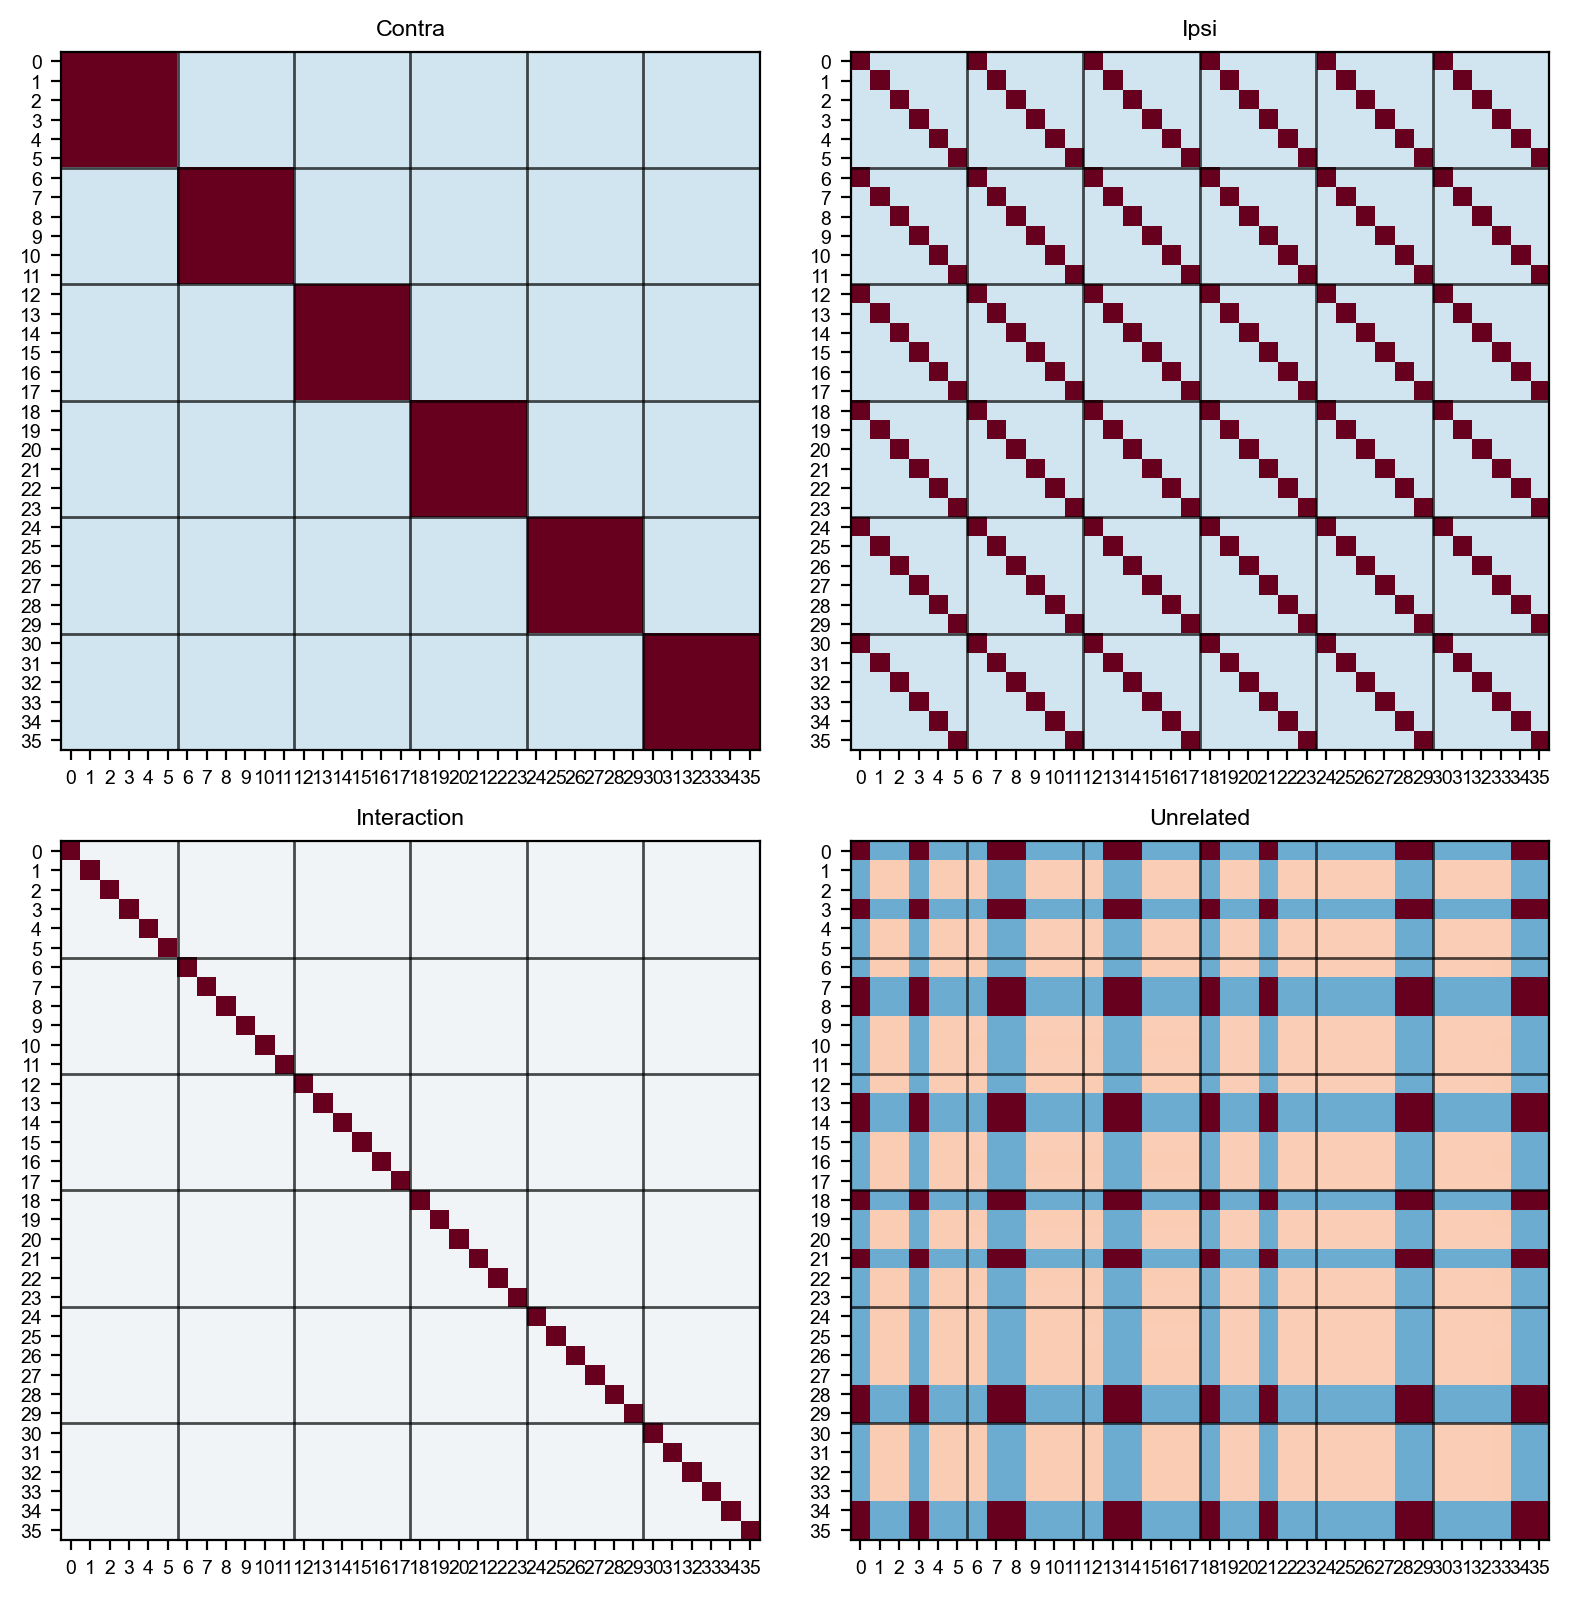

In [ ]:
# retina quality inline figs:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

# one-hot unrelated conditions:
cov_unrel = np.zeros((ncond,ncond)) #np.eye(ncond)
idx_unrel = [1,2,4,5, 6,9,10,11, 12,15,16,17, 19,20,22,23, 24,25,26,27, 30,31,32,33]
for i in range(len(idx_unrel)):
    for j in range(len(idx_unrel)):
        if i != j:
            cov_unrel[idx_unrel[i], idx_unrel[j]] = 1
F_unrel = np.zeros((ncond,1))
F_unrel[idx_unrel,0] = 1
cov_unrel = F_unrel @ F_unrel.T

# OLS components:
# Generate the three model components, each one as a fixed model
A = np.zeros((ncond, 6))
for i in range(6):
    A[i*6:(i+1)*6, i] = 1.0
B = np.tile(np.eye(6), (6, 1))
I = np.eye(ncond)
# Orthogonalize the interaction effect
X = np.c_[A, B]
Io = I - X @ np.linalg.pinv(X) @ I
Io = I # not orthogonalized interaction

# Now Build the second moment matrix and create the full model
# for data generation:
Gc = np.zeros((4, ncond, ncond))
Gc[0] = pcm.centering(ncond) @ A @ A.T @ pcm.centering(ncond) # contra
Gc[1] = pcm.centering(ncond) @ B @ B.T @ pcm.centering(ncond) # ipsi
Gc[2] = pcm.centering(ncond) @ Io @ Io.T @ pcm.centering(ncond) # interaction
Gc[3] = pcm.centering(ncond) @ cov_unrel @ pcm.centering(ncond) # unrelated

# visualize components:
fig, axes = plt.subplots(2,2, figsize=(8,8))
for i in range(4):
    ax = axes.flatten()[i]
    im = ax.imshow(Gc[i], cmap=cmap, vmin=-np.max(np.abs(Gc[i])), vmax=np.max(np.abs(Gc[i])))
    # draw lines to separate the 6x6 blocks:
    block = 6
    bounds = [b-0.5 for b in range(block, ncond, block)]
    for b in bounds:
        ax.axhline(b, color='k', lw=1, alpha=0.7)
        ax.axvline(b, color='k', lw=1, alpha=0.7)
    ax.set_title(['Contra', 'Ipsi', 'Interaction', 'Unrelated'][i])
    ax.set_xticks(np.arange(ncond))
    ax.set_yticks(np.arange(ncond))
plt.tight_layout()
plt.show()



# Marginal 6by6

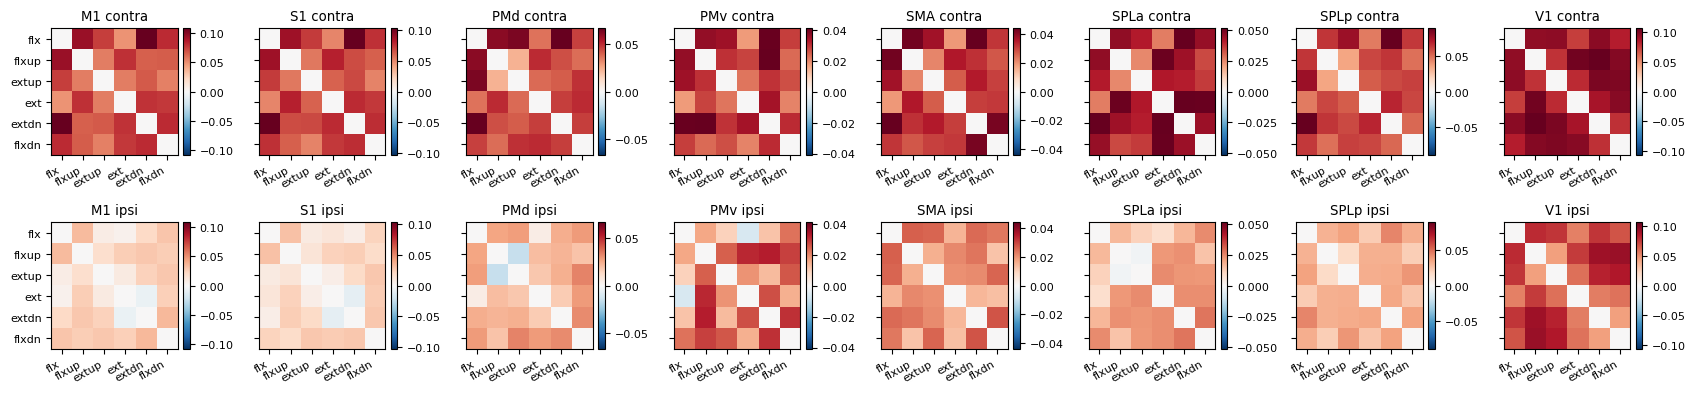

/var/folders/sc/kmc7_9gn2hqd_lrnhdt_2s580000gn/T/ipykernel_54578/2728289485.py:201: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')


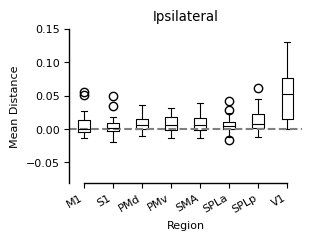

/var/folders/sc/kmc7_9gn2hqd_lrnhdt_2s580000gn/T/ipykernel_54578/2728289485.py:216: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')


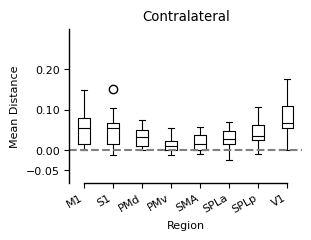

M1:
    contra: t=6.416, p=1.5130e-06
    ipsi: t=2.019, p=5.5266e-02
S1:
    contra: t=6.160, p=2.7708e-06
    ipsi: t=1.507, p=1.4535e-01
PMd:
    contra: t=6.372, p=1.6745e-06
    ipsi: t=3.285, p=3.2473e-03
PMv:
    contra: t=3.674, p=1.2600e-03
    ipsi: t=2.717, p=1.2295e-02
SMA:
    contra: t=4.565, p=1.3753e-04
    ipsi: t=2.939, p=7.3712e-03
SPLa:
    contra: t=5.994, p=4.1160e-06
    ipsi: t=2.431, p=2.3272e-02
SPLp:
    contra: t=6.217, p=2.4201e-06
    ipsi: t=3.828, p=8.6235e-04
V1:
    contra: t=7.993, p=4.3548e-08
    ipsi: t=6.152, p=2.8190e-06


In [ ]:
labels = ['flx', 'flxup', 'extup', 'ext', 'extdn', 'flxdn']
cmap = 'RdBu_r' 
sn_bad = [102, 103]

regions = ['M1','S1','PMd','PMv','SMA','SPLa','SPLp','V1']
dataset_marginal_within = {'region':[], 'hem': [], 'type': [], 'labels': [], 'Y': []}
df = {'region':[], 'hem':[], 'type': [], 'distances':[], 'mean_distance':[]}

for region in regions:
    conditions = ['lhand_marginal', 'rhand_marginal', 'lhand_marginal', 'rhand_marginal']
    rois = [f'{region}_R',f'{region}_L',f'{region}_L',f'{region}_R']
    for roi, condition in zip(rois, conditions):
        data, cond_vec, part_vec = [], [], []
        file_path = os.path.join(analysisDir, f'pwbeta_{roi}.npz')
        d = np.load(file_path, allow_pickle=True)

        subject = d['subject']
        indices = [k for k, s in enumerate(subject) if s not in sn_bad]
        
        subject = d['subject'][indices]
        cond_name_tmp = d['cond_intrinsic_vec'][indices]
        cond_vec_tmp = d['cond_num_vec'][indices]
        data_tmp = d['beta_white'][indices]
        part_tmp = d['part_vec'][indices]
        
        for i_sub in range(len(subject)):
            # Filter for the current condition
            if condition == 'lhand_marginal':
                if roi.endswith('_R'):
                    cond_type = 'contra'
                else:
                    cond_type = 'ipsi'
                Y = []
                subj_part = []
                subj_cond = []
                # loop on each direction
                for cond_num, direction in enumerate(labels):
                    # in each partition:
                    for k in range(1,11):
                        # bimanual trials that left hand goes in that direction:
                        tmp_name = f'bi:{direction}_'
                        idx1 = np.array([(tmp_name in tmp) for tmp in cond_name_tmp[i_sub]])
                        idx2 = np.array([(k == tmp) for tmp in part_tmp[i_sub]])
                        idx = idx1 & idx2
                        y_tmp = np.mean(data_tmp[i_sub][idx,:], axis=0)
                        Y = np.vstack((Y, y_tmp)) if len(Y) else y_tmp
                    subj_part = np.int64(np.concatenate((subj_part,np.arange(1,11))))
                    condition_name = f'lhand:{direction}'
                    # find the condition numbers corresponding to this condition:
                    idx = (cond_name_tmp[i_sub] == condition_name) & (part_tmp[i_sub] == 1)
                    subj_cond.extend([cond_vec_tmp[i_sub][idx][0]] * 10)

            if condition == 'rhand_marginal':
                if roi.endswith('_L'):
                    cond_type = 'contra'
                else:
                    cond_type = 'ipsi'
                Y = []
                subj_part = []
                subj_cond = []
                # loop on each direction
                for cond_num, direction in enumerate(labels):
                    # in each partition:
                    for k in range(1,11):
                        # bimanual trials that right hand goes in that direction:
                        tmp_name = f'_{direction}'
                        idx1 = np.array([tmp.endswith(tmp_name) for tmp in cond_name_tmp[i_sub]])
                        idx2 = np.array([(k == tmp) for tmp in part_tmp[i_sub]])
                        idx = idx1 & idx2
                        y_tmp = np.mean(data_tmp[i_sub][idx,:], axis=0)
                        Y = np.vstack((Y, y_tmp)) if len(Y) else y_tmp
                    subj_part = np.int64(np.concatenate((subj_part,np.arange(1,11))))
                    condition_name = f'rhand:{direction}'
                    # find the condition numbers corresponding to this condition:
                    idx = (cond_name_tmp[i_sub] == condition_name) & (part_tmp[i_sub] == 1)
                    subj_cond.extend([cond_vec_tmp[i_sub][idx][0]] * 10)

            data.append(Y)
            cond_vec.append(np.array(subj_cond))
            part_vec.append(subj_part)

        Y = []
        for i_sub in range(len(data)):
            obs_des = {'cond_vec': cond_vec[i_sub], 'part_vec': part_vec[i_sub]}
            Y.append(pcm.dataset.Dataset(data[i_sub], obs_descriptors=obs_des))

        # save PCM dataset:
        dataset_marginal_within['region'].append(region)
        dataset_marginal_within['hem'].append(roi[-1])
        dataset_marginal_within['type'].append(cond_type)
        dataset_marginal_within['labels'].append(labels)
        dataset_marginal_within['Y'].append(Y)
        
dataset_marginal_within = pd.DataFrame(dataset_marginal_within)
dataset_marginal_within.to_pickle(os.path.join(analysisDir, 'dataset_marginal_within.pkl'))

# --- RDM Calculation ---
plt.rcParams.update({'font.size': 8})
fig, axes = plt.subplots(2, len(regions), figsize=(17,4), sharey=True)
for i, region in enumerate(regions):
    subset = dataset_marginal_within[(dataset_marginal_within['region'] == f'{region}') & 
                                        (dataset_marginal_within['type'] == 'contra')]
    Y1 = subset['Y'].iloc[0]
    Y2 = subset['Y'].iloc[1]
    Y = Y1 + Y2  # concatenate the two lists of datasets
    labels = subset['labels'].iloc[0]
    N = len(Y)
    ncond = len(labels)
    G_hat = np.zeros((N, ncond, ncond))
    for i_sub in range(N):
        G_hat[i_sub, :, :], _ = pcm.est_G_crossval(Y[i_sub].measurements,
                                                    Y[i_sub].obs_descriptors['cond_vec'],
                                                    Y[i_sub].obs_descriptors['part_vec'],
                                                    X=pcm.matrix.indicator(Y[i_sub].obs_descriptors['part_vec']))
        d_tmp = pcm.G_to_dist(G_hat[i_sub, :, :])
        d_tmp = np.sign(d_tmp) * np.sqrt(np.abs(d_tmp))
        # select the upper triangle of d excluding the diagonal
        triu_indices = np.triu_indices(ncond, k=1)
        d_upper = d_tmp[triu_indices]
        d_upper_mean = np.mean(d_upper)
        # save in df:
        df['distances'].append(d_upper)
        df['mean_distance'].append(d_upper_mean)
        df['region'].append(region)
        df['hem'].append('R' if i_sub < 12 else 'L')
        df['type'].append('contra')
        
    G_hat_avg = np.mean(G_hat, axis=0)
    D_avg = pcm.G_to_dist(G_hat_avg)
    D_avg = np.sign(D_avg) * np.sqrt(np.abs(D_avg))
    vmin = -np.max(np.abs(D_avg))
    vmax = np.max(np.abs(D_avg))
    axes[0, i].imshow(D_avg,vmin=-vmax,vmax=vmax,cmap=cmap)
    # color bar:
    sm = ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=-vmax, vmax=vmax))
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=axes[0, i], fraction=0.046, pad=0.04)
    cbar.ax.tick_params(labelsize=8)
    axes[0, i].set_title(f'{region} contra')
    axes[0, i].set_xticks(np.arange(len(labels)))
    axes[0,i].set_xticklabels(labels, rotation=30, ha='right')
    axes[0, i].set_yticks(np.arange(len(labels)))
    axes[0,i].set_yticklabels(labels, ha='right')

    subset = dataset_marginal_within[(dataset_marginal_within['region'] == f'{region}') & 
                                        (dataset_marginal_within['type'] == 'ipsi')]
    Y1 = subset['Y'].iloc[0]
    Y2 = subset['Y'].iloc[1]
    Y = Y1 + Y2  # concatenate the two lists of datasets
    labels = subset['labels'].iloc[0]
    N = len(Y)
    ncond = len(labels)
    G_hat = np.zeros((N, ncond, ncond))
    for i_sub in range(N):
        G_hat[i_sub, :, :], _ = pcm.est_G_crossval(Y[i_sub].measurements,
                                                    Y[i_sub].obs_descriptors['cond_vec'],
                                                    Y[i_sub].obs_descriptors['part_vec'],
                                                    X=pcm.matrix.indicator(Y[i_sub].obs_descriptors['part_vec']))
        d_tmp = pcm.G_to_dist(G_hat[i_sub, :, :])
        d_tmp = np.sign(d_tmp) * np.sqrt(np.abs(d_tmp))
        # select the upper triangle of d excluding the diagonal
        triu_indices = np.triu_indices(ncond, k=1)
        d_upper = d_tmp[triu_indices]
        d_upper_mean = np.mean(d_upper)
        # save in df:
        df['distances'].append(d_upper)
        df['mean_distance'].append(d_upper_mean)
        df['region'].append(region)
        df['hem'].append('L' if i_sub < 12 else 'R')
        df['type'].append('ipsi')

    G_hat_avg = np.mean(G_hat, axis=0)
    D_avg = pcm.G_to_dist(G_hat_avg)
    D_avg = np.sign(D_avg) * np.sqrt(np.abs(D_avg))
    axes[1, i].imshow(D_avg,vmin=-vmax,vmax=vmax,cmap=cmap)
    # color bar:
    sm = ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=-vmax, vmax=vmax))
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=axes[1, i], fraction=0.046, pad=0.04)
    cbar.ax.tick_params(labelsize=8)
    axes[1, i].set_title(f'{region} ipsi')
    axes[1, i].set_xticks(np.arange(len(labels)))
    axes[1,i].set_xticklabels(labels, rotation=30, ha='right')
    axes[1, i].set_yticks(np.arange(len(labels)))
    axes[1,i].set_yticklabels(labels, ha='right')

plt.tight_layout()
plt.show()

df_marginal = pd.DataFrame(df)

# Create a dot plot for the mean distances
df_ipsi_marginal = df_marginal[df_marginal['type'] == 'ipsi']
fig, ax = plt.subplots(figsize=(3, 2))
sns.boxplot(data=df_ipsi_marginal, x='region', y='mean_distance', ax=ax, fill=False, color='black', width=0.4, linewidth=0.8)
ax.axhline(0, color='grey', linestyle='--', linewidth=1.5)
ax.set_xlabel('Region')
ax.set_ylabel('Mean Distance')
ax.set_title('Ipsilateral')
ax.set_ylim((-0.08, 0.15))
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
# ax.set_yticks([-0.05, 0, 0.1, 0.2])
utils.please.make_it_pretty(ax)
# plt.savefig('/Users/aghavamp/Desktop/Projects/bimanual_wrist/figures/RDMs/avgdist_uni_ipsi.pdf', bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(figsize=(3, 2))
df_contra_marginal = df_marginal[df_marginal['type'] == 'contra']
sns.boxplot(data=df_contra_marginal, x='region', y='mean_distance', ax=ax, fill=False, color='black', width=0.4, linewidth=0.8)
ax.axhline(0, color='grey', linestyle='--', linewidth=1.5)
ax.set_xlabel('Region')
ax.set_ylabel('Mean Distance')
ax.set_title('Contralateral')
plt.ylim(-0.08, 0.3)
ax.set_yticks([-0.05, 0, 0.1, 0.2])
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
utils.please.make_it_pretty(ax)
# plt.savefig('/Users/aghavamp/Desktop/Projects/bimanual_wrist/figures/RDMs/avgdist_uni_contra.pdf', bbox_inches='tight')
plt.show()

# ttest distances > 0:
from scipy.stats import ttest_1samp
for region in regions:
    subset = df_marginal[df_marginal['region'] == region]
    print(f'{region}:')
    for cond_type in ['contra','ipsi']:
        sub_subset = subset[(subset['type'] == cond_type)]
        t_stat, p_val = ttest_1samp(sub_subset['mean_distance'], 0)
        
        print(f'    {cond_type}: t={t_stat:.3f}, p={p_val:.4e}')



# Marginal 12by12

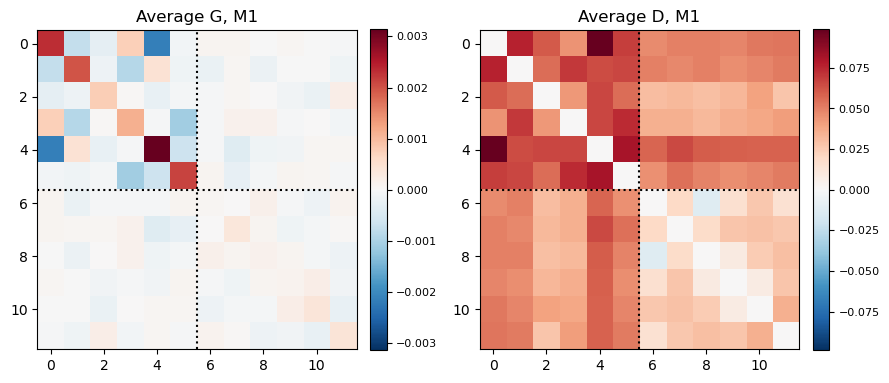

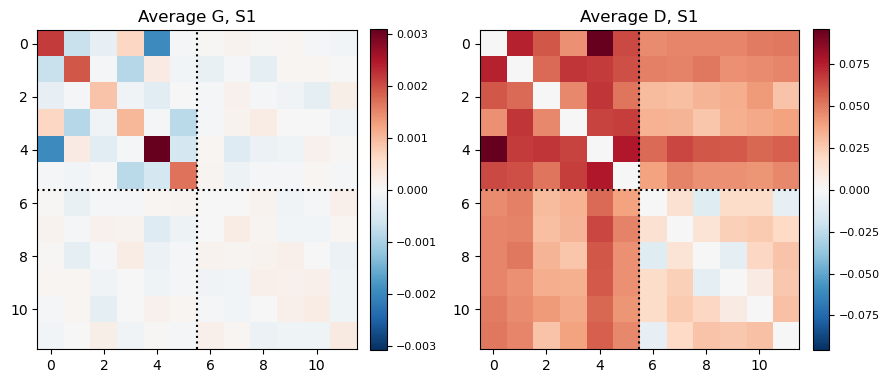

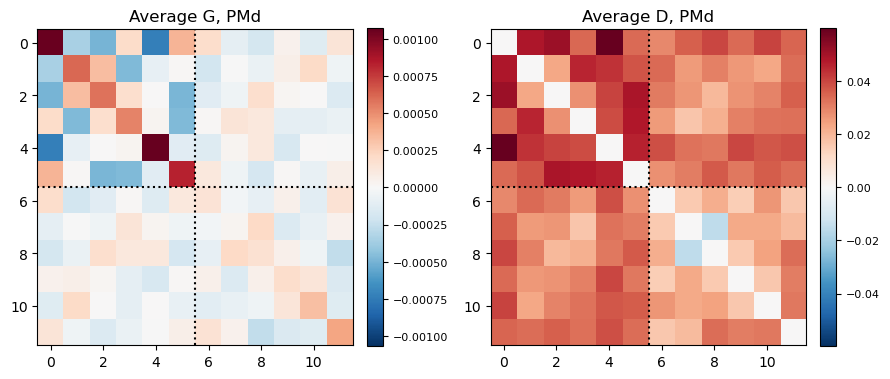

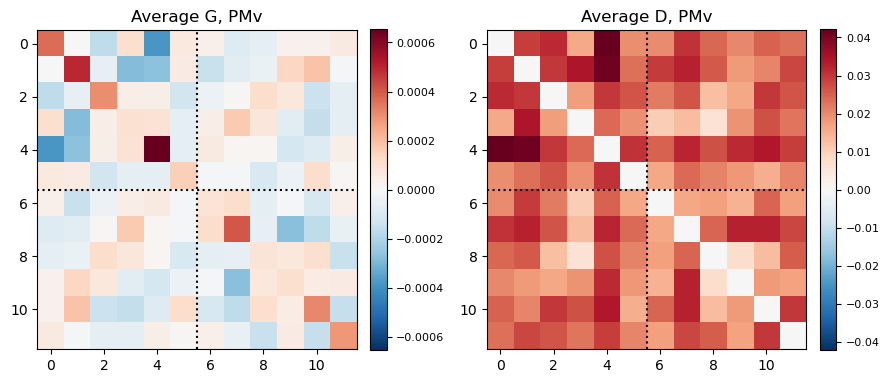

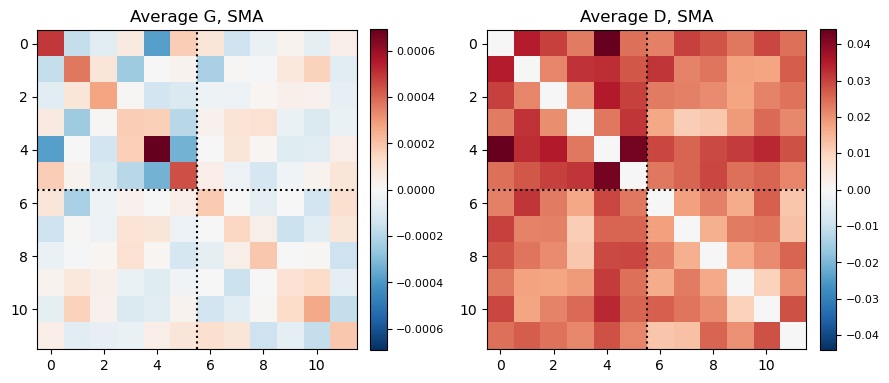

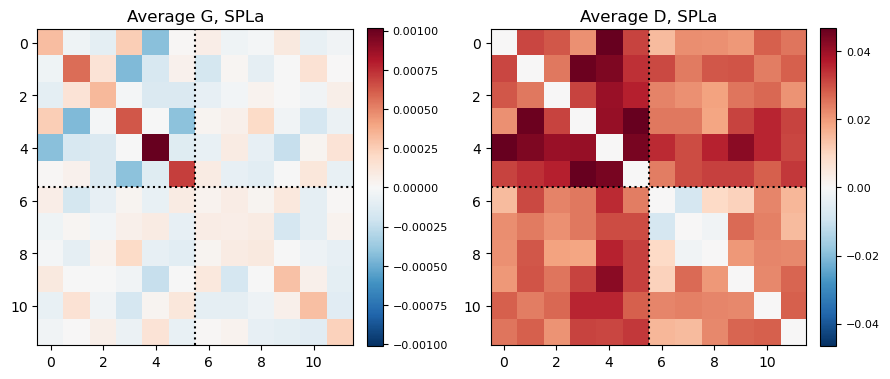

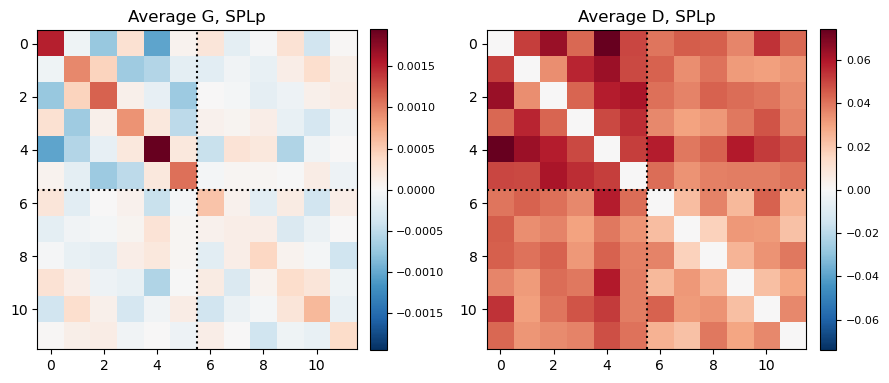

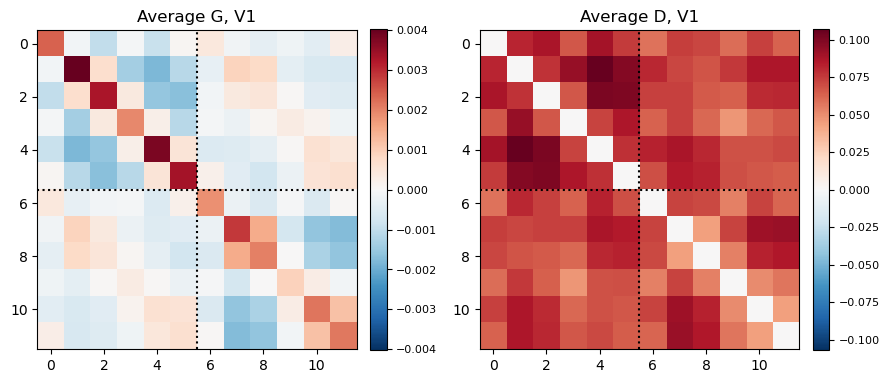

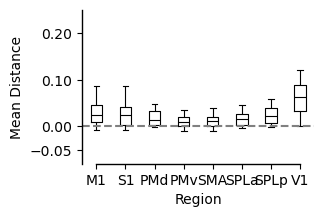

/var/folders/sc/kmc7_9gn2hqd_lrnhdt_2s580000gn/T/ipykernel_15279/1654412521.py:165: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30)


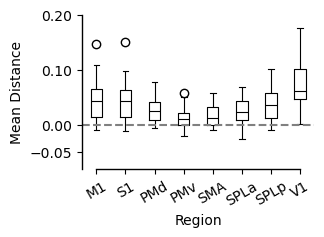

/var/folders/sc/kmc7_9gn2hqd_lrnhdt_2s580000gn/T/ipykernel_15279/1654412521.py:176: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30)


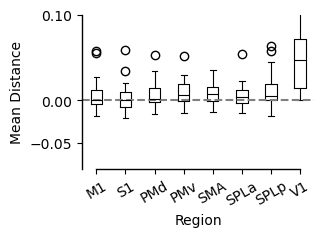


Region: M1
ipsi: t=1.81, p=0.0414
contra: t=5.85, p=0.0000

Region: S1
ipsi: t=0.95, p=0.1761
contra: t=5.52, p=0.0000

Region: PMd
ipsi: t=2.20, p=0.0192
contra: t=5.46, p=0.0000

Region: PMv
ipsi: t=2.73, p=0.0060
contra: t=3.16, p=0.0022

Region: SMA
ipsi: t=2.89, p=0.0042
contra: t=4.08, p=0.0002

Region: SPLa
ipsi: t=1.99, p=0.0293
contra: t=5.20, p=0.0000

Region: SPLp
ipsi: t=2.83, p=0.0047
contra: t=5.64, p=0.0000

Region: V1
ipsi: t=5.81, p=0.0000
contra: t=7.69, p=0.0000


In [ ]:
labels = ['flx', 'flxup', 'extup', 'ext', 'extdn', 'flxdn']
cmap = 'RdBu_r'
sn_bad = [102, 103]
df = {'sn':[], 'roi':[], 'hem':[], 'distances':[], 'mean_distance':[], 'mean_contra':[], 'mean_ipsi':[]}
regions = ['M1','S1','PMd','PMv','SMA','SPLa','SPLp','V1']

hem = ['L', 'R']
for region in regions:
    data, cond_vec, part_vec = [], [], []
    for i_hem, h in enumerate(hem):
        roi = f'{region}_{h}'
        file_path = os.path.join(analysisDir, f'pwbeta_{roi}.npz')
        d = np.load(file_path, allow_pickle=True)

        subject = d['subject']
        indices = [k for k, s in enumerate(subject) if s not in sn_bad]
        
        subject = d['subject'][indices]
        cond_name_tmp = d['cond_intrinsic_vec'][indices]
        cond_vec_tmp = d['cond_num_vec'][indices]
        data_tmp = d['beta_white'][indices]
        part_tmp = d['part_vec'][indices]
        
        for i_sub in range(len(subject)):
            Y = []
            subj_part = []
            subj_cond = []

            # lhand marginal:
            for cond_num, direction in enumerate(labels):
                # in each partition:
                for k in range(1,11):
                    # bimanual trials that left hand goes in that direction:
                    tmp_name = f'bi:{direction}_'
                    idx1 = np.array([(tmp_name in tmp) for tmp in cond_name_tmp[i_sub]])
                    idx2 = np.array([(k == tmp) for tmp in part_tmp[i_sub]])
                    idx = idx1 & idx2
                    y_tmp = np.mean(data_tmp[i_sub][idx,:], axis=0)
                    Y = np.vstack((Y, y_tmp)) if len(Y) else y_tmp
                subj_part = np.int64(np.concatenate((subj_part,np.arange(1,11))))
                condition_name = f'lhand:{direction}'
                # find the condition numbers corresponding to this condition:
                idx = (cond_name_tmp[i_sub] == condition_name) & (part_tmp[i_sub] == 1)
                subj_cond.extend([cond_vec_tmp[i_sub][idx][0]] * 10)

            # rhand marginal:
            for cond_num, direction in enumerate(labels):
                # in each partition:
                for k in range(1,11):
                    # bimanual trials that right hand goes in that direction:
                    tmp_name = f'_{direction}'
                    idx1 = np.array([(tmp_name in tmp) for tmp in cond_name_tmp[i_sub]])
                    idx2 = np.array([(k == tmp) for tmp in part_tmp[i_sub]])
                    idx = idx1 & idx2
                    y_tmp = np.mean(data_tmp[i_sub][idx,:], axis=0)
                    Y = np.vstack((Y, y_tmp)) if len(Y) else y_tmp
                subj_part = np.int64(np.concatenate((subj_part,np.arange(1,11))))
                condition_name = f'rhand:{direction}'
                # find the condition numbers corresponding to this condition:
                idx = (cond_name_tmp[i_sub] == condition_name) & (part_tmp[i_sub] == 1)
                subj_cond.extend([cond_vec_tmp[i_sub][idx][0]] * 10)

            subj_cond = np.array(subj_cond)
            # Sort based on Hemisphere to have contralateral first:
            if h == 'L':
                tmp = subj_cond.copy()
                subj_cond[tmp > 5] = tmp[tmp > 5] - 6
                subj_cond[tmp <= 5] = tmp[tmp <= 5] + 6 

            data.append(Y)
            cond_vec.append(subj_cond)
            part_vec.append(subj_part)

    Y = []
    # --- Build dataset ---
    for i_sub in range(len(data)):
        obs_des = {'cond_vec': cond_vec[i_sub], 'part_vec': part_vec[i_sub]}
        Y.append(pcm.dataset.Dataset(data[i_sub], obs_descriptors=obs_des))

    # --- RDM Calculation ---
    N = len(Y)
    ncond = len(np.unique(Y[0].obs_descriptors['cond_vec']))
    G_hat = np.zeros((N, ncond, ncond))
    for i_sub in range(N):
        G_hat[i_sub, :, :], _ = pcm.est_G_crossval(Y[i_sub].measurements,
                                                    Y[i_sub].obs_descriptors['cond_vec'],
                                                    Y[i_sub].obs_descriptors['part_vec'],
                                                    X=pcm.matrix.indicator(Y[i_sub].obs_descriptors['part_vec']))
        dist = pcm.G_to_dist(G_hat[i_sub, :, :])
        dist = np.sign(dist) * np.sqrt(np.abs(dist))
        # select the upper triangle of d excluding the diagonal
        triu_indices = np.triu_indices(ncond, k=1)
        d_upper = dist[triu_indices]
        df['distances'].append(d_upper)
        df['mean_distance'].append(np.mean(d_upper))

        # contra:
        dist = pcm.G_to_dist(G_hat[i_sub, :, :])
        dist = np.sign(dist) * np.sqrt(np.abs(dist))
        dist = dist[:6, :6]
        triu_indices = np.triu_indices(6, k=1)
        d_upper = dist[triu_indices]
        df['mean_contra'].append(np.mean(d_upper))

        # ipsi:
        dist = pcm.G_to_dist(G_hat[i_sub, :, :])
        dist = np.sign(dist) * np.sqrt(np.abs(dist))
        dist = dist[6:12, 6:12]
        triu_indices = np.triu_indices(6, k=1)
        d_upper = dist[triu_indices]
        df['mean_ipsi'].append(np.mean(d_upper))
        
        df['roi'].append(region)
        df['sn'].append(i_sub)
        df['hem'].append(hem)
        
    # avg G:
    fig, ax = plt.subplots(1,2,figsize=(9,4))
    G_hat_avg = np.mean(G_hat, axis=0)
    vmax = np.abs(G_hat_avg).max()
    ax[0].imshow(G_hat_avg, vmin=-vmax, vmax=vmax, cmap=cmap)
    sm = ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=-vmax, vmax=vmax))
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax[0], fraction=0.046, pad=0.04)
    cbar.ax.tick_params(labelsize=8)
    ax[0].set_title(f'Average G, {region}')
    ax[0].axhline(5.5, color='k', linestyle=':', linewidth=1.5)
    ax[0].axvline(5.5, color='k', linestyle=':', linewidth=1.5)

    # avg D:
    D_avg = pcm.G_to_dist(G_hat_avg)
    D_avg = np.sign(D_avg) * np.sqrt(np.abs(D_avg))
    vmax = np.abs(D_avg).max()
    ax[1].imshow(D_avg, vmin=-vmax, vmax=vmax, cmap=cmap)
    sm = ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=-vmax, vmax=vmax))
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax[1], fraction=0.046, pad=0.04)
    cbar.ax.tick_params(labelsize=8)
    ax[1].set_title(f'Average D, {region}')
    ax[1].axhline(5.5, color='k', linestyle=':', linewidth=1.5)
    ax[1].axvline(5.5, color='k', linestyle=':', linewidth=1.5)

    plt.tight_layout()
    plt.show() 

df_marginal = pd.DataFrame(df)

# Create a dot plot for the mean distances
fig, ax = plt.subplots(figsize=(3, 2))
sns.boxplot(data=df_marginal, x='roi', y='mean_distance', ax=ax, fill=False, color='black', width=0.4, linewidth=0.8)
ax.axhline(0, color='grey', linestyle='--', linewidth=1.5)
ax.set_xlabel('Region')
ax.set_ylabel('Mean Distance')
plt.ylim(-0.08, 0.25)
ax.set_yticks([-0.05, 0, 0.1, 0.2])
utils.please.make_it_pretty(ax)
plt.show()

fig, ax = plt.subplots(figsize=(3, 2))
sns.boxplot(data=df_marginal, x='roi', y='mean_contra', ax=ax, fill=False, color='black', width=0.4, linewidth=0.8)
ax.axhline(0, color='grey', linestyle='--', linewidth=1.5)
ax.set_xlabel('Region')
ax.set_ylabel('Mean Distance')
plt.ylim(-0.08, 0.2)
ax.set_xticklabels(ax.get_xticklabels(), rotation=30)
ax.set_yticks([-0.05, 0, 0.1, 0.2])
utils.please.make_it_pretty(ax)
plt.show()

fig, ax = plt.subplots(figsize=(3, 2))
sns.boxplot(data=df_marginal, x='roi', y='mean_ipsi', ax=ax, fill=False, color='black', width=0.4, linewidth=0.8)
ax.axhline(0, color='grey', linestyle='--', linewidth=1.5)
ax.set_xlabel('Region')
ax.set_ylabel('Mean Distance')
plt.ylim(-0.08, 0.1)
ax.set_xticklabels(ax.get_xticklabels(), rotation=30)
ax.set_yticks([-0.05, 0, 0.1])
utils.please.make_it_pretty(ax)
plt.show()

# t-test on mean_ipsi > 0:
from scipy import stats
for region in regions:
    print(f'\nRegion: {region}')
    tmp = df_marginal[df_marginal['roi'] == region]
    t, p = stats.ttest_1samp(tmp['mean_ipsi'], 0, alternative='greater')
    print(f'ipsi: t={t:.2f}, p={p:.4f}')
    tmp = df_marginal[df_marginal['roi'] == region]
    t, p = stats.ttest_1samp(tmp['mean_contra'], 0, alternative='greater')
    print(f'contra: t={t:.2f}, p={p:.4f}')



# Noise simulation

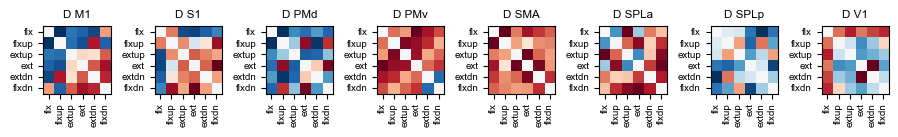

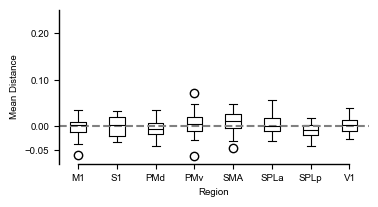

Region: M1, t(23): -0.2133942432091614, p-value: 0.5835501366617177
Region: S1, t(23): 0.194127124234387, p-value: 0.4238903605097959
Region: PMd, t(23): -1.0350129243871444, p-value: 0.844288338009826
Region: PMv, t(23): 1.0797510049587078, p-value: 0.14572312208790392
Region: SMA, t(23): 2.04544147414344, p-value: 0.026207511631272242
Region: SPLa, t(23): 0.9997610859709138, p-value: 0.16391448576506773
Region: SPLp, t(23): -2.2692021630690684, p-value: 0.9835256016960147
Region: V1, t(23): 0.8333695151284958, p-value: 0.20660374080345872


In [4]:
labels = ['flx', 'flxup', 'extup', 'ext', 'extdn', 'flxdn']
cmap = 'RdBu_r'
sn_bad = [102,103]
regions = ['M1','S1','PMd','PMv','SMA','SPLa','SPLp','V1']
conditions = ['noise','noise']
df = {'sn':[], 'roi':[], 'hem':[], 'distances':[], 'mean_distance':[]}

RDMs_noise = {'region':[], 'labels': [], 'G': [], 'D': []}

plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 7
fig, axes = plt.subplots(1, len(regions), figsize=(9,3))
for i_region, region in enumerate(regions):
    rois = [f'{region}_L', f'{region}_R']
    data, cond_vec, part_vec = [], [], []
    for roi, condition in zip(rois, conditions):
        file_path = os.path.join(analysisDir, f'pwbeta_{roi}.npz')
        d = np.load(file_path, allow_pickle=True)
        
        subject = d['subject']
        indices = [k for k, s in enumerate(subject) if s not in sn_bad]

        subject = d['subject'][indices]
        cond_name_tmp = d['cond_intrinsic_vec'][indices]
        cond_vec_tmp = d['cond_num_vec'][indices]
        data_tmp = d['beta_white'][indices]
        part_tmp = d['part_vec'][indices]

        # generate pure noise data:
        data_tmp = [np.random.normal(0,0.5,size=tmp.shape) for tmp in data_tmp]

        for i_sub in range(len(subject)):
            # Filter for the current condition
            idx = [j for j, c in enumerate(cond_name_tmp[i_sub]) if 'rhand' in c]
            Y = data_tmp[i_sub][idx, :]
            subj_cond = cond_vec_tmp[i_sub][idx]
            subj_part = part_tmp[i_sub][idx]

            data.append(Y)
            cond_vec.append(np.array(subj_cond))
            part_vec.append(subj_part)

    Y = []
    # --- RDM Calculation ---
    for i_sub in range(len(data)):
        obs_des = {'cond_vec': cond_vec[i_sub], 'part_vec': part_vec[i_sub]}
        Y.append(pcm.dataset.Dataset(data[i_sub], obs_descriptors=obs_des))
    
    N = len(Y)
    ncond = 6
    G_hat = np.zeros((N, ncond, ncond))
    for i_sub in range(N):
        G_hat[i_sub, :, :], _ = pcm.est_G_crossval(Y[i_sub].measurements,
                                                    Y[i_sub].obs_descriptors['cond_vec'],
                                                    Y[i_sub].obs_descriptors['part_vec'],
                                                    X=pcm.matrix.indicator(Y[i_sub].obs_descriptors['part_vec']))
        dist = pcm.G_to_dist(G_hat[i_sub, :, :])
        dist = np.sign(dist) * np.sqrt(np.abs(dist))
        # select the upper triangle of d excluding the diagonal
        triu_indices = np.triu_indices(ncond, k=1)
        d_upper = dist[triu_indices]
        # save in df:
        df['distances'].append(d_upper)
        df['mean_distance'].append(np.mean(d_upper))
        df['roi'].append(region)
        # if i_sub is bigger than len of subject:
        if i_sub > len(subject)-1:
            df['sn'].append(subject[i_sub - len(subject)])
            df['hem'].append('R')
        else:
            df['sn'].append(subject[i_sub])
            df['hem'].append('L')

    G_hat_avg = np.mean(G_hat, axis=0)
    D_avg = pcm.G_to_dist(G_hat_avg)
    D_avg = np.sign(D_avg) * np.sqrt(np.abs(D_avg))
    RDMs_noise['region'].append(region)
    RDMs_noise['G'].append(G_hat_avg)
    RDMs_noise['D'].append(D_avg)
    RDMs_noise['labels'].append(labels)

    vmin = -np.max(np.abs(D_avg))
    vmax = np.max(np.abs(D_avg))
    axes[i_region].imshow(D_avg, cmap='RdBu_r', vmin=vmin, vmax=vmax)
    # plt.colorbar(axes[i_region].imshow(G, cmap='RdBu_r', vmin=vmin, vmax=vmax), ax=axes[i_region])
    axes[i_region].set_title(f'D {region}')
    axes[i_region].set_xticks([0,1,2,3,4,5])
    axes[i_region].set_xticklabels(labels, rotation=90)
    axes[i_region].set_yticks([0,1,2,3,4,5])
    axes[i_region].set_yticklabels(labels)

plt.tight_layout()
plt.show()

df_noise = pd.DataFrame(df)

# Create a dot plot for the mean distances
fig, ax = plt.subplots(figsize=(4, 2))
sns.boxplot(data=df_noise, x='roi', y='mean_distance', ax=ax, fill=False, color='black', width=0.4, linewidth=0.8)
ax.axhline(0, color='grey', linestyle='--', linewidth=1.5)
ax.set_xlabel('Region')
ax.set_ylabel('Mean Distance')
plt.ylim(-0.08, 0.25)
ax.set_yticks([-0.05, 0, 0.1, 0.2])
utils.please.make_it_pretty(ax)
plt.show()

# ttest > 0:
from scipy.stats import ttest_1samp
ttest_results = []
for i_region, region in enumerate(regions):
    # Get the distances for this region
    dists = df_noise['mean_distance'][df_noise['roi'] == region].values
    # Perform a one-sample t-test against the null hypothesis (mean = 0)
    t_stat, p_val = ttest_1samp(dists, 0, alternative='greater')
    print(f'Region: {region}, t({len(dists)-1}): {t_stat}, p-value: {p_val}')

RDMs_noise= pd.DataFrame(RDMs_noise)



# avg distance plot

In [6]:
# combine df_contra, df_ipsi and df_bi and add a column 'lateral' to indicate
df_contra['lateral'] = 'contra'
df_ipsi['lateral'] = 'ipsi'
df_bi['lateral'] = 'bi'
df_noise['lateral'] = 'noise'
df_combined = pd.concat([df_contra, df_ipsi, df_bi, df_noise], ignore_index=True)
df_combined.to_csv(os.path.join(analysisDir, 'avg_distances.csv'))



NameError: name 'df_contra' is not defined

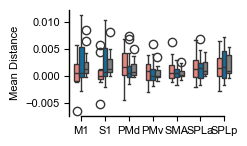

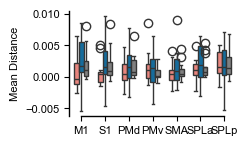

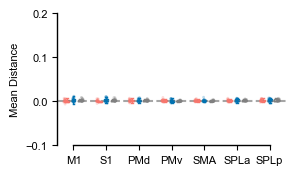

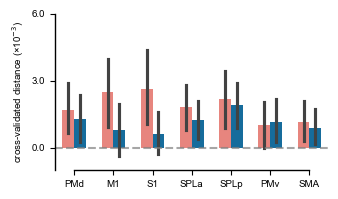

M1 contra L t-test: t(11) = 2.06, p = 0.0318
M1 contra R t-test: t(11) = 2.13, p = 0.0281
M1 ipsi L t-test: t(11) = 0.80, p = 0.2191
M1 ipsi R t-test: t(11) = 0.99, p = 0.1721
M1 bi L t-test: t(13) = 3.22, p = 0.0034
M1 bi R t-test: t(13) = 2.94, p = 0.0057
M1 noise L t-test: t(11) = 0.19, p = 0.4274
M1 noise R t-test: t(11) = -0.40, p = 0.6517
S1 contra L t-test: t(11) = 2.35, p = 0.0193
S1 contra R t-test: t(11) = 2.08, p = 0.0308
S1 ipsi L t-test: t(11) = 0.62, p = 0.2733
S1 ipsi R t-test: t(11) = 1.18, p = 0.1313
S1 bi L t-test: t(13) = 3.65, p = 0.0015
S1 bi R t-test: t(13) = 2.70, p = 0.0092
S1 noise L t-test: t(11) = 0.65, p = 0.2651
S1 noise R t-test: t(11) = -0.39, p = 0.6465
PMd contra L t-test: t(11) = 1.82, p = 0.0480
PMd contra R t-test: t(11) = 2.21, p = 0.0246
PMd ipsi L t-test: t(11) = 2.07, p = 0.0315
PMd ipsi R t-test: t(11) = 1.28, p = 0.1134
PMd bi L t-test: t(13) = 3.41, p = 0.0023
PMd bi R t-test: t(13) = 3.05, p = 0.0047
PMd noise L t-test: t(11) = 0.81, p = 0.21

In [ ]:
import matplotlib.ticker as ticker

df = pd.read_csv(os.path.join(analysisDir, 'avg_distances.csv'))
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 8

df = df[df.roi != 'V1']

fig, ax = plt.subplots(figsize=(2.5,1.5))
sns.boxplot(data=df[df.hem=='L'], x='roi', y='mean_distance', hue='lateral', ax=ax, width=0.6, palette=['#F8766D','#0072B2','#808080'], hue_order=['ipsi','contra','bi'],legend=False,
            order=['M1','S1','PMd','PMv','SMA','SPLa','SPLp'])
# plt.ylim((0,0.8))
# plt.title(f'Left Hemisphere')
plt.ylabel('Mean Distance')
plt.xlabel('')
utils.please.make_it_pretty(ax=ax)
plt.tight_layout()
plt.savefig(f'../figures/RDMs/mean_distance_leftHemisphere.pdf', bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(2.5,1.5))
sns.boxplot(data=df[df.hem=='R'], x='roi', y='mean_distance', hue='lateral', ax=ax, width=0.6, palette=['#F8766D','#0072B2','#808080'],  hue_order=['ipsi','contra','bi'], legend=False,
            order=['M1','S1','PMd','PMv','SMA','SPLa','SPLp'])
# plt.ylim((0,0.8))
# plt.title(f'Right Hemisphere')
plt.ylabel('Mean Distance')
plt.xlabel('')
utils.please.make_it_pretty(ax=ax)
plt.tight_layout()
plt.savefig(f'../figures/RDMs/mean_distance_rightHemisphere.pdf', bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(3,1.8))
sns.boxplot(data=df, x='roi', y='mean_distance', hue='lateral', ax=ax, width=0.6, palette=['#F8766D','#0072B2','#808080'],  hue_order=['ipsi','contra','bi'], legend=False,
            order=['M1','S1','PMd','PMv','SMA','SPLa','SPLp'], fliersize=0, linewidth=1, gap=0.4, fill=False)
sns.stripplot(data=df, x='roi', y='mean_distance', hue='lateral', ax=ax, palette=['#F8766D','#0072B2','#808080'],  hue_order=['ipsi','contra','bi'],
              order=['M1','S1','PMd','PMv','SMA','SPLa','SPLp'], dodge=True, size=2, alpha=0.25, legend=False)
ax.axhline(0, color='grey', linestyle='--', linewidth=1.5, alpha=0.7)
plt.ylim((-0.1,0.2))
ax.set_yticks([-0.1, 0, 0.1, 0.2])
# plt.title(f'Right Hemisphere')
plt.ylabel('Mean Distance')
plt.xlabel('')
utils.please.make_it_pretty(ax=ax)
plt.tight_layout()
plt.savefig(f'../figures/RDMs/mean_distance.pdf', bbox_inches="tight")
plt.show()


plt.rcParams['font.size'] = 7
fig, ax = plt.subplots(figsize=(3.4,2))
df_uni = df[(df.lateral!='bi') & (df.lateral!='noise')].copy()
# df_uni.loc[df_uni.lateral=='ipsi', 'mean_distance'] = 0
# df_uni.loc[df_uni.lateral=='contra', 'mean_distance'] = 0
sns.barplot(data=df_uni, x='roi', y='mean_distance', hue='lateral', ax=ax, width=0.6, palette=['#F8766D','#0072B2'],  hue_order=['contra','ipsi'], legend=False,
            order=['PMd','M1','S1','SPLa','SPLp','PMv','SMA'], fill=True)
ax.axhline(0, color='grey', linestyle='--', linewidth=1.5, alpha=0.7)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: f'{x*1e3:.1f}'))
plt.ylim((-0.001,0.006))
plt.yticks([0, 0.003, 0.006])
# ax.set_yticks([0, 0.07])
# plt.title(f'Right Hemisphere')
ax.set_ylabel(r'cross-validated distance (×10$^{-3}$)')
plt.xlabel('')
utils.please.make_it_pretty(ax=ax)
plt.tight_layout()
plt.savefig(f'../figures/RDMs/avgdist_uni.pdf', bbox_inches="tight")
plt.show()


# Separate barplot for hemispheres:
# plt.rcParams['font.size'] = 12
# fig, ax = plt.subplots(1,2, figsize=(10,3), sharey=True)
# df_uni_L = df_uni[df_uni.hem=='L']
# sns.barplot(data=df_uni_L, x='roi', y='mean_distance', hue='lateral', ax=ax[0], width=0.6, palette=['#F8766D','#0072B2'],  hue_order=['contra','ipsi'], legend=False,
#             order=['M1','S1','PMd','PMv','SMA','SPLa','SPLp'], linewidth=1, gap=0.2, fill=True)
# ax[0].axhline(0, color='grey', linestyle='--', linewidth=1.5, alpha=0.7)
# plt.ylim((-0.001,0.006))
# # ax[0].set_yticks([0, 0.07])
# ax[0].set_title('Left Hemisphere')
# ax[0].set_ylabel('Distance Between Conditions')
# plt.xlabel('')
# utils.please.make_it_pretty(ax=ax[0])
# df_uni_R = df_uni[df_uni.hem=='R']
# sns.barplot(data=df_uni_R, x='roi', y='mean_distance', hue='lateral', ax=ax[1], width=0.6, palette=['#F8766D','#0072B2'],  hue_order=['contra','ipsi'], legend=False,
#             order=['M1','S1','PMd','PMv','SMA','SPLa','SPLp'], linewidth=1, gap=0.2, fill=True)
# ax[1].axhline(0, color='grey', linestyle='--', linewidth=1.5, alpha=0.7)
# plt.ylim((-0.001,0.006))
# # ax[1].set_yticks([0, 0.07])
# ax[1].set_title('Right Hemisphere')
# ax[1].set_ylabel('Distance Between Conditions')
# plt.xlabel('')
# utils.please.make_it_pretty(ax=ax[1])
# plt.tight_layout()
# plt.show()


# ttest against 0 for every region within each lateral category and each hemisphere:
from scipy.stats import ttest_1samp
from statsmodels.stats.multitest import multipletests

for region in df['roi'].unique():
    for lateral in df['lateral'].unique():
        for hem in df['hem'].unique():
            data = df[(df['roi'] == region) & (df['lateral'] == lateral) & (df['hem'] == hem)]['mean_distance']
            t_stat, p_val = ttest_1samp(data, 0, alternative='greater')
            print(f'{region} {lateral} {hem} t-test: t({len(data)-1}) = {t_stat:.2f}, p = {p_val:.4f}')



# average

### estimate cross-val variance and distance

In [4]:
regions = ['M1','S1','PMd','PMv','SMA','SPLa','SPLp','V1']
labels = ['flx', 'flxup', 'extup', 'ext', 'extdn', 'flxdn']
cmap = 'RdBu_r'
ncond = 6

var_df = {'region': [], 'hem': [], 'sn': [], 'component': [], 'd2': [], 'd': []}
for region in regions:
    # load dataset:
    file_path_save = os.path.join(analysisDir, f'pcm_dataset_6by6_{region}.npz')
    D = np.load(file_path_save, allow_pickle=True)
    hemisphere = D['hemisphere'].tolist()
    identifier = D['identifier']
    sn = D['sn'].tolist()
    D = D['Y'].tolist()

    # load bimanual dataset:
    file_path = os.path.join(analysisDir, f'pcm_dataset_bimanual_{region}.npz')
    D_bimanual = np.load(file_path, allow_pickle=True)
    hem_bi = D_bimanual['hemisphere'].tolist()
    D_bimanual = D_bimanual['Y'].tolist()

    N = len(D)
    G_hat = np.zeros((N, ncond, ncond))
    RDM_hat = np.zeros((N, ncond, ncond))
    for i in range(N):
        G_hat[i, :, :], _ = pcm.est_G_crossval(D[i].measurements,
                                                D[i].obs_descriptors['cond_vec'],
                                                D[i].obs_descriptors['part_vec'],
                                                X=pcm.matrix.indicator(D[i].obs_descriptors['part_vec']))
        RDM_hat[i, :, :] = pcm.G_to_dist(G_hat[i, :, :])

    bi_G = np.zeros((len(D_bimanual), 36, 36))
    for i in range(len(D_bimanual)):
        bi_G[i, :, :], _ = pcm.est_G_crossval(D_bimanual[i].measurements,
                                     D_bimanual[i].obs_descriptors['cond_vec'],
                                     D_bimanual[i].obs_descriptors['part_vec'],
                                     X=pcm.matrix.indicator(D_bimanual[i].obs_descriptors['part_vec']))
        RDM_bi = pcm.G_to_dist(bi_G[i, :, :])

    contra_idx = (identifier == 'contra').flatten()
    ipsi_idx = (identifier == 'ipsi').flatten()

    contra_G = G_hat[contra_idx,:,:]
    ipsi_G = G_hat[ipsi_idx,:,:]
    
    hem_contra = np.array(hemisphere)[contra_idx]
    hem_ipsi = np.array(hemisphere)[ipsi_idx]

    # variance measurement:
    for i in range(contra_G.shape[0]):
        var_df['region'].append(region)
        var_df['hem'].append(hem_contra[i])
        var_df['sn'].append(sn[i])
        var_df['component'].append('contra')
        tmp_d2 = 2/(6-1) * np.trace(contra_G[i,:,:])
        var_df['d2'].append(tmp_d2)
        var_df['d'].append(np.sign(tmp_d2) * np.sqrt(np.abs(tmp_d2)))
        
        var_df['region'].append(region)
        var_df['hem'].append(hem_ipsi[i])
        var_df['sn'].append(sn[i])
        var_df['component'].append('ipsi')
        tmp_d2 = 2/(6-1) * np.trace(ipsi_G[i,:,:])
        var_df['d2'].append(tmp_d2)
        var_df['d'].append(np.sign(tmp_d2) * np.sqrt(np.abs(tmp_d2)))

        var_df['region'].append(region)
        var_df['hem'].append(hem_bi[i])
        var_df['sn'].append(sn[i])
        var_df['component'].append('bi')
        tmp_d2 = 2/(36-1) * np.trace(bi_G[i,:,:])
        var_df['d2'].append(tmp_d2)
        var_df['d'].append(np.sign(tmp_d2) * np.sqrt(np.abs(tmp_d2)))

var_df = pd.DataFrame(var_df)
var_df.to_csv(os.path.join(analysisDir, 'unimanual_distances.csv'), index=False)



### plot

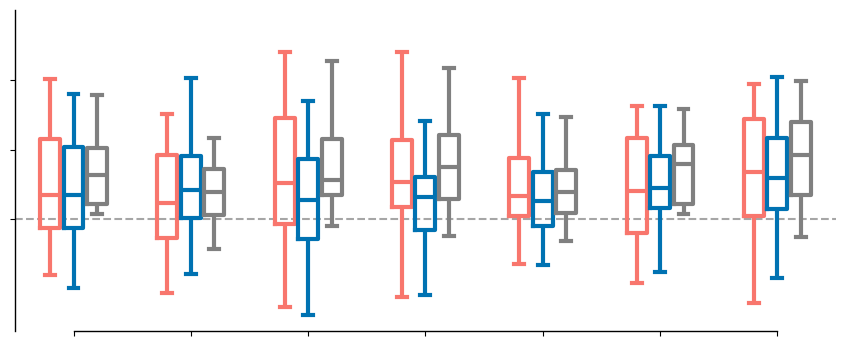

In [14]:
import matplotlib.ticker as ticker
var_df = pd.read_csv(os.path.join(analysisDir, 'unimanual_distances.csv'))

plt.rcParams['font.size'] = 8
# fig, ax = plt.subplots(figsize=(4.4,1.7))
# fig, ax = plt.subplots(figsize=(4.4,2.3))
fig, ax = plt.subplots(figsize=(8.5,3.5))
ax.axhline(0, color='grey', linestyle='--', linewidth=1.5, alpha=0.7)
sns.boxplot(data=var_df, x='region', y='d', hue='component', ax=ax, width=0.6, gap=0.15,
            palette=['#F8766D','#0072B2','#808080'],  
            hue_order=['contra','ipsi','bi'], legend=False, 
            order=['PMd','PMv','M1','S1','SMA','SPLa','SPLp'], fill=False, fliersize=0, linewidth=3)
plt.ylim((-0.008,0.015))
plt.yticks([0, 0.005, 0.01])
ax.set_yticklabels('')
ax.set_xticklabels('')
# ax.set_yticks([0, 0.07])
# plt.title(f'Right Hemisphere')
ax.set_ylabel(f'')
plt.xlabel('')
utils.please.make_it_pretty(ax=ax)
plt.tight_layout()
plt.savefig(f'../figures/RDMs/avgdist_boxplot.pdf', bbox_inches="tight")
plt.show()



### STATS

#### stats component > 0

In [ ]:
from scipy import stats

results_contra = []
results_ipsi = []
results_bi = []
for region in regions:
    var_df_region = var_df[var_df['region'] == region]
    contra_d = var_df_region[var_df_region['component'] == 'contra']['d'].values
    ipsi_d = var_df_region[var_df_region['component'] == 'ipsi']['d'].values
    bi_d = var_df_region[var_df_region['component'] == 'bi']['d'].values

    # t-test contra > 0:
    t_stat, p_val = stats.ttest_1samp(contra_d, 0, alternative='greater')
    results_contra.append({
            'region': region,
            'mean': np.mean(contra_d),
            'dof': len(contra_d)-1,
            't_stat': t_stat,
            'p_unc': p_val
        })

    # t-test ipsi > 0:
    t_stat, p_val = stats.ttest_1samp(ipsi_d, 0, alternative='greater')
    results_ipsi.append({
            'region': region,
            'mean': np.mean(ipsi_d),
            'dof': len(ipsi_d)-1,
            't_stat': t_stat,
            'p_unc': p_val
        })

    # t-test bi > 0:
    t_stat, p_val = stats.ttest_1samp(bi_d, 0, alternative='greater')
    results_bi.append({
            'region': region,
            'mean': np.mean(bi_d),
            'dof': len(bi_d)-1,
            't_stat': t_stat,
            'p_unc': p_val
        })

results_contra = pd.DataFrame(results_contra)
results_ipsi = pd.DataFrame(results_ipsi)
results_bi = pd.DataFrame(results_bi)

# multiple comparison correction:
from statsmodels.stats.multitest import multipletests
# contra:
reject, p_corr, _, _ = multipletests(results_contra['p_unc'], alpha=0.05, method='fdr_bh')
results_contra['p_fdr'] = p_corr
results_contra['reject_H0'] = reject
print('Contra results:')
print(results_contra)
# ipsi:
reject, p_corr, _, _ = multipletests(results_ipsi['p_unc'], alpha=0.05, method='fdr_bh')
results_ipsi['p_fdr'] = p_corr
results_ipsi['reject_H0'] = reject
print('\nIpsi results:')
print(results_ipsi)
# bi:
reject, p_corr, _, _ = multipletests(results_bi['p_unc'], alpha=0.05, method='fdr_bh')
results_bi['p_fdr'] = p_corr
results_bi['reject_H0'] = reject
print('\nBi results:')
print(results_bi.to_string())



Contra results:
  region      mean  dof    t_stat         p_unc         p_fdr  reject_H0
0     M1  0.003285   23  3.281352  1.636915e-03  2.182554e-03       True
1     S1  0.003568   23  3.752507  5.189962e-04  1.383990e-03       True
2    PMd  0.002618   23  3.352380  1.379379e-03  2.182554e-03       True
3    PMv  0.001514   23  1.996880  2.890255e-02  2.890255e-02       True
4    SMA  0.002093   23  3.390892  1.256685e-03  2.182554e-03       True
5   SPLa  0.002401   23  3.127006  2.367174e-03  2.705341e-03       True
6   SPLp  0.003371   23  3.842717  4.153556e-04  1.383990e-03       True
7     V1  0.006191   23  8.241511  1.282610e-08  1.026088e-07       True

Ipsi results:
  region      mean  dof    t_stat     p_unc     p_fdr  reject_H0
0     M1  0.001465   23  1.807824  0.041865  0.041865       True
1     S1  0.001506   23  2.382611  0.012920  0.014766       True
2    PMd  0.002331   23  3.065825  0.002736  0.004378       True
3    PMv  0.002203   23  3.296084  0.001580  0.00316

#### contra vs ipsi

In [18]:
from scipy import stats
regions = ['PMd','M1','S1','SPLa','SPLp','PMv','SMA']

results = []
for region in regions:
    var_df_region = var_df[var_df['region'] == region]
    contra_d2 = var_df_region[var_df_region['component'] == 'contra']['d'].values
    ipsi_d2 = var_df_region[var_df_region['component'] == 'ipsi']['d'].values
    
    # t-test contra > ipsi:
    t_stat, p_val = stats.ttest_rel(contra_d2, ipsi_d2, alternative='greater')
    results.append({
            'region': region,
            'dof': len(contra_d2)-1,
            't_stat': t_stat,
            'p_unc': p_val
        })

results = pd.DataFrame(results)

# multiple comparison correction across regions:
from statsmodels.stats.multitest import multipletests
reject, p_corr, _, _ = multipletests(results['p_unc'], alpha=0.05, method='fdr_bh')
results['p_corr'] = p_corr
results['reject_H0'] = reject
print('Contra vs Ipsi results:')
print(results)



Contra vs Ipsi results:
  region  dof    t_stat     p_unc    p_corr  reject_H0
0    PMd   23  1.045608  0.153304  0.297914      False
1     M1   23  2.701449  0.006369  0.022290       True
2     S1   23  3.490381  0.000987  0.006908       True
3   SPLa   23  0.322585  0.374962  0.465208      False
4   SPLp   23  0.259577  0.398750  0.465208      False
5    PMv   23 -0.821907  0.790216  0.790216      False
6    SMA   23  0.973418  0.170236  0.297914      False
